# O1 depth-policy analytics across seven landscapes

This notebook analyzes the complete 7-landscape experiment (benchmark seeds 40-46, SMAC seeds 0-9). General rankings and leave-one-landscape-out validation include all 109 policies. Stage-depth plots use the 40 sampled three-stage policies with switches after trials 250 and 660.

Selection uses mean final simple regret (lower is better). Confidence bands are 95% Student-t intervals across SMAC seeds.

In [1]:

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import t

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})

RELATIVE_EXPERIMENT = Path('experiments/synthaticBench/o1_deterministic/depth_policies/09_big_experiment')
candidates = [Path.cwd(), Path.cwd() / RELATIVE_EXPERIMENT]
EXPERIMENT = next((p.resolve() for p in candidates if (p / 'o1_big_experiment_runner.py').exists()), None)
if EXPERIMENT is None:
    raise FileNotFoundError('Run from the repository root or the 09_big_experiment directory.')
OUTPUT = EXPERIMENT / 'smac_output'
BENCHMARK_SEEDS = tuple(range(40, 47))
SMAC_SEEDS = tuple(range(10))
STAGE_SWITCHES = (250, 660)
STAGE_LABELS = ('Stage 1 (1-250)', 'Stage 2 (251-660)', 'Stage 3 (661-1000)')
STAGE_DEPTHS = (5, 10, 15, 20)
N_TRIALS = 1000
BASE_POLICY_COUNT = 109
EXPECTED_RUNS_PER_POLICY = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS)
TOP_CURVES = 5
CONSENSUS_POLICY = 'consensus_ramp_9_11_13_16_19_20'
FIXED_CURVE_CONTROLS = ['fixed_depth_5', 'fixed_depth_10', 'fixed_depth_15']
LOO_TOP_NS = (1, 3, 5)
print(f'Experiment: {EXPERIMENT}')


Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/09_big_experiment


## Load and validate trajectories

The cell checks the experiment metadata, trajectory lengths, seven landscapes, ten SMAC seeds, and uniqueness of every policy/landscape/seed combination.

In [2]:

rows = []
curves = {}
for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    spec = data['policy_spec']
    stage_depths = tuple(spec.get('stage_depths') or ())
    best_regret = np.asarray(data['best_regret'], dtype=float)
    best_so_far = np.asarray(data['best_so_far'], dtype=float)
    key = (int(data['benchmark_seed']), int(data['smac_seed']), data['policy'])
    if key in curves:
        raise ValueError(f'Duplicate trajectory: {key}')
    curves[key] = best_so_far
    rows.append({
        'benchmark_seed': key[0], 'smac_seed': key[1], 'policy': key[2],
        'policy_family': data['policy_family'], 'policy_type': data['policy_type'],
        'is_adaptive': data['policy_type'] != 'fixed',
        'fixed_depth': spec.get('fixed_depth'),
        'd1': stage_depths[0] if len(stage_depths) == 3 else np.nan,
        'd2': stage_depths[1] if len(stage_depths) == 3 else np.nan,
        'd3': stage_depths[2] if len(stage_depths) == 3 else np.nan,
        'final_regret': float(best_regret[-1]),
        'mean_regret': float(best_regret.mean()),
        'log_auc': float(np.log10(np.maximum(best_regret, 1e-300)).mean()),
        'n_trials': int(data['n_trials']),
        'random_design_probability': float(data['random_design_probability']),
        'pythonhashseed': str(data['pythonhashseed']),
        'path': path,
    })

raw_results = pd.DataFrame(rows)
if raw_results.empty:
    raise FileNotFoundError(f'No trajectories found below {OUTPUT}')
assert tuple(sorted(raw_results.benchmark_seed.unique())) == BENCHMARK_SEEDS, 'Expected exactly seven landscapes.'
assert tuple(sorted(raw_results.smac_seed.unique())) == SMAC_SEEDS, 'Expected SMAC seeds 0-9.'
assert raw_results.n_trials.eq(N_TRIALS).all()
assert raw_results.random_design_probability.eq(0.0).all()
assert raw_results.pythonhashseed.eq('12345').all()

per_policy_counts = raw_results.groupby('policy').size().sort_index()
complete_policies = per_policy_counts[per_policy_counts == EXPECTED_RUNS_PER_POLICY].index
incomplete_policies = per_policy_counts[per_policy_counts != EXPECTED_RUNS_PER_POLICY]
if not incomplete_policies.empty:
    print('Incomplete policies excluded from aggregate analysis until all 70 trajectories exist:')
    display(incomplete_policies.rename('available_trajectories').to_frame())

results = raw_results[raw_results.policy.isin(complete_policies)].copy()
curves = {key: value for key, value in curves.items() if key[2] in set(complete_policies)}
assert results.policy.nunique() >= BASE_POLICY_COUNT, (
    f'Expected at least the {BASE_POLICY_COUNT} baseline policies, found {results.policy.nunique()} complete policies.'
)
assert results.groupby('policy').size().eq(EXPECTED_RUNS_PER_POLICY).all()

if CONSENSUS_POLICY in complete_policies:
    print(f'Consensus policy included: {CONSENSUS_POLICY}')
elif CONSENSUS_POLICY in set(raw_results.policy):
    available = int(per_policy_counts.loc[CONSENSUS_POLICY])
    print(f'Consensus policy found but incomplete: {available}/{EXPECTED_RUNS_PER_POLICY}; excluded for now.')
else:
    print(f'Consensus policy not found yet: {CONSENSUS_POLICY}')

completion = (results.groupby(['policy_family', 'benchmark_seed'])
              .agg(policies=('policy', 'nunique'), trajectories=('policy', 'size'), smac_seeds=('smac_seed', 'nunique'))
              .reset_index())
print(f'Loaded {len(raw_results):,} trajectories; using {len(results):,} complete-policy trajectories, {results.policy.nunique()} policies, and {results.benchmark_seed.nunique()} landscapes.')
display(completion.pivot(index='policy_family', columns='benchmark_seed', values='trajectories'))


Consensus policy included: consensus_ramp_9_11_13_16_19_20
Loaded 7,700 trajectories; using 7,700 complete-policy trajectories, 110 policies, and 7 landscapes.


benchmark_seed,40,41,42,43,44,45,46
policy_family,,,,,,,
alternate_plus_4_minus_2_every_100,80,80,80,80,80,80,80
consensus_ramp,10,10,10,10,10,10,10
cycle_every_50,40,40,40,40,40,40,40
fixed,170,170,170,170,170,170,170
increase_1_every_100,100,100,100,100,100,100,100
increase_2_every_100,100,100,100,100,100,100,100
increase_2_every_100_hold_after_500,100,100,100,100,100,100,100
increase_3_every_100,100,100,100,100,100,100,100
sampled_three_stage,400,400,400,400,400,400,400


## Top 5 and top 15 policies for every landscape

Each policy is averaged over its ten SMAC seeds, then ranked independently on each benchmark landscape. The displayed top-15 table includes a `top_5` flag.

In [3]:
landscape_policy = (results.groupby(['benchmark_seed', 'policy', 'policy_family', 'policy_type', 'is_adaptive'], as_index=False)
                    .agg(mean_final_regret=('final_regret', 'mean'),
                         std_final_regret=('final_regret', 'std'),
                         mean_log_auc=('log_auc', 'mean'),
                         n_seeds=('smac_seed', 'nunique')))
landscape_policy['rank'] = landscape_policy.groupby('benchmark_seed')['mean_final_regret'].rank(method='min')
landscape_policy['top_5'] = landscape_policy['rank'] <= 5
landscape_policy['top_15'] = landscape_policy['rank'] <= 15

top_tables = {}
for benchmark_seed in BENCHMARK_SEEDS:
    table = (landscape_policy.query('benchmark_seed == @benchmark_seed')
             .sort_values(['mean_final_regret', 'policy'])
             .head(15)
             [['rank', 'top_5', 'policy', 'policy_family', 'mean_final_regret', 'std_final_regret', 'mean_log_auc']])
    top_tables[benchmark_seed] = table
    print(f'Benchmark seed {benchmark_seed}: top 5 / top 15 policies')
    display(table.style.format({'rank': '{:.0f}', 'mean_final_regret': '{:.5g}', 'std_final_regret': '{:.5g}', 'mean_log_auc': '{:.4f}'})
            .background_gradient(subset=['mean_final_regret'], cmap='YlGn_r'))

Benchmark seed 40: top 5 / top 15 policies


,rank,top_5,policy,policy_family,mean_final_regret,std_final_regret,mean_log_auc
65,1,True,increase_3_every_100_start_5,increase_3_every_100,3146.6,1110.3,4.1623
39,2,True,increase_1_every_100_start_9,increase_1_every_100,3763.2,933.56,4.2162
52,3,True,increase_2_every_100_start_6,increase_2_every_100,3890.6,1063.3,4.1839
3,4,True,alternate_plus_4_minus_2_every_100_start_5,alternate_plus_4_minus_2_every_100,3894.6,1467,4.2294
68,5,True,increase_3_every_100_start_8,increase_3_every_100,3936.2,1223.2,4.2011
104,6,False,three_stage_5_15_15,sampled_three_stage,3948.2,1207.1,4.1626
58,7,False,increase_2_every_100_start_9,increase_2_every_100,3973.9,1452,4.1861
6,8,False,alternate_plus_4_minus_2_every_100_start_8,alternate_plus_4_minus_2_every_100,4024.2,1555.5,4.1896
76,9,False,three_stage_10_20_20,sampled_three_stage,4041.3,1158.8,4.1749
23,10,False,fixed_depth_20,fixed,4138.2,1194.1,4.2219


Benchmark seed 41: top 5 / top 15 policies


,rank,top_5,policy,policy_family,mean_final_regret,std_final_regret,mean_log_auc
186,1,True,three_stage_10_20_20,sampled_three_stage,1831.5,673.22,3.7492
118,2,True,consensus_ramp_9_11_13_16_19_20,consensus_ramp,2140.9,925.66,3.6925
132,3,True,fixed_depth_19,fixed,2220.7,1121,3.7249
177,4,True,increase_3_every_100_start_7,increase_3_every_100,2232.4,1391.4,3.6987
172,5,True,increase_3_every_100_start_12,increase_3_every_100,2237.9,1468.8,3.7214
110,6,False,alternate_plus_4_minus_2_every_100_start_10,alternate_plus_4_minus_2_every_100,2243.6,767.92,3.7528
111,7,False,alternate_plus_4_minus_2_every_100_start_11,alternate_plus_4_minus_2_every_100,2281.5,788.95,3.7692
164,8,False,increase_2_every_100_start_7,increase_2_every_100,2391.2,1186.3,3.8402
152,9,False,increase_2_every_100_start_11,increase_2_every_100,2429.6,1087.3,3.7643
153,9,False,increase_2_every_100_start_11_hold_after_500,increase_2_every_100_hold_after_500,2429.6,1087.3,3.7643


Benchmark seed 42: top 5 / top 15 policies


...

,rank,top_5,policy,policy_family,mean_final_regret,std_final_regret,mean_log_auc
446,1,True,alternate_plus_4_minus_2_every_100_start_8,alternate_plus_4_minus_2_every_100,5908.8,1938.1,4.3682
522,2,True,three_stage_15_10_20,sampled_three_stage,5930.3,2494.2,4.3908
470,3,True,increase_1_every_100_start_10,increase_1_every_100,5978.8,1480.1,4.3533
440,4,True,alternate_plus_4_minus_2_every_100_start_10,alternate_plus_4_minus_2_every_100,6291.4,2419.3,4.3458
460,5,True,fixed_depth_17,fixed,6309.9,2148.2,4.3385
510,6,False,three_stage_10_10_15,sampled_three_stage,6522.4,2533.3,4.3769
478,7,False,increase_1_every_100_start_8,increase_1_every_100,6524.3,1822.2,4.3980
444,8,False,alternate_plus_4_minus_2_every_100_start_6,alternate_plus_4_minus_2_every_100,6531.4,3232.6,4.4121
473,9,False,increase_1_every_100_start_13,increase_1_every_100,6580.1,2862.4,4.3474
457,10,False,fixed_depth_14,fixed,6666.8,2706.7,4.3327


Benchmark seed 45: top 5 / top 15 policies


,rank,top_5,policy,policy_family,mean_final_regret,std_final_regret,mean_log_auc
607,1,True,increase_2_every_100_start_8_hold_after_500,increase_2_every_100_hold_after_500,4050.3,1113.9,4.1858
552,2,True,alternate_plus_4_minus_2_every_100_start_12,alternate_plus_4_minus_2_every_100,4167.4,2244.8,4.2022
569,3,True,fixed_depth_16,fixed,4171.6,1483.4,4.2065
656,4,True,three_stage_5_20_15,sampled_three_stage,4206.3,1941.6,4.1412
606,5,True,increase_2_every_100_start_8,increase_2_every_100,4217.6,787.26,4.1952
557,6,False,alternate_plus_4_minus_2_every_100_start_9,alternate_plus_4_minus_2_every_100,4221.8,1586.7,4.2285
572,7,False,fixed_depth_19,fixed,4240.1,1698.6,4.2173
614,8,False,increase_3_every_100_start_4,increase_3_every_100,4351.7,1486,4.1993
582,9,False,increase_1_every_100_start_12,increase_1_every_100,4358.4,1352.6,4.2129
551,10,False,alternate_plus_4_minus_2_every_100_start_11,alternate_plus_4_minus_2_every_100,4360.7,1881,4.1992


Benchmark seed 46: top 5 / top 15 policies


,rank,top_5,policy,policy_family,mean_final_regret,std_final_regret,mean_log_auc
722,1,True,increase_3_every_100_start_12,increase_3_every_100,1523.8,673.85,3.6120
681,2,True,fixed_depth_18,fixed,1877.3,1035.2,3.6158
702,3,True,increase_2_every_100_start_11,increase_2_every_100,2126.6,920.6,3.6901
703,3,True,increase_2_every_100_start_11_hold_after_500,increase_2_every_100_hold_after_500,2126.6,920.6,3.6901
753,5,True,three_stage_20_15_20,sampled_three_stage,2134.8,1245.2,3.6674
726,6,False,increase_3_every_100_start_6,increase_3_every_100,2143.6,761.99,3.7192
704,7,False,increase_2_every_100_start_12,increase_2_every_100,2223,867.32,3.6490
705,7,False,increase_2_every_100_start_12_hold_after_500,increase_2_every_100_hold_after_500,2223,867.32,3.6490
736,9,False,three_stage_10_20_20,sampled_three_stage,2254.9,857.96,3.7171
728,10,False,increase_3_every_100_start_8,increase_3_every_100,2319.1,1634.9,3.6739


## Iteration vs best-so-far with 95% confidence intervals

Every landscape shows its five best policies selected by mean final regret plus fixed-depth controls 5, 10, and 15. Fixed controls use dashed lines. Curves are means across ten SMAC seeds; shaded regions are pointwise 95% Student-t confidence intervals. Selection and visualization use the same landscape, so these figures are descriptive rather than out-of-sample comparisons.

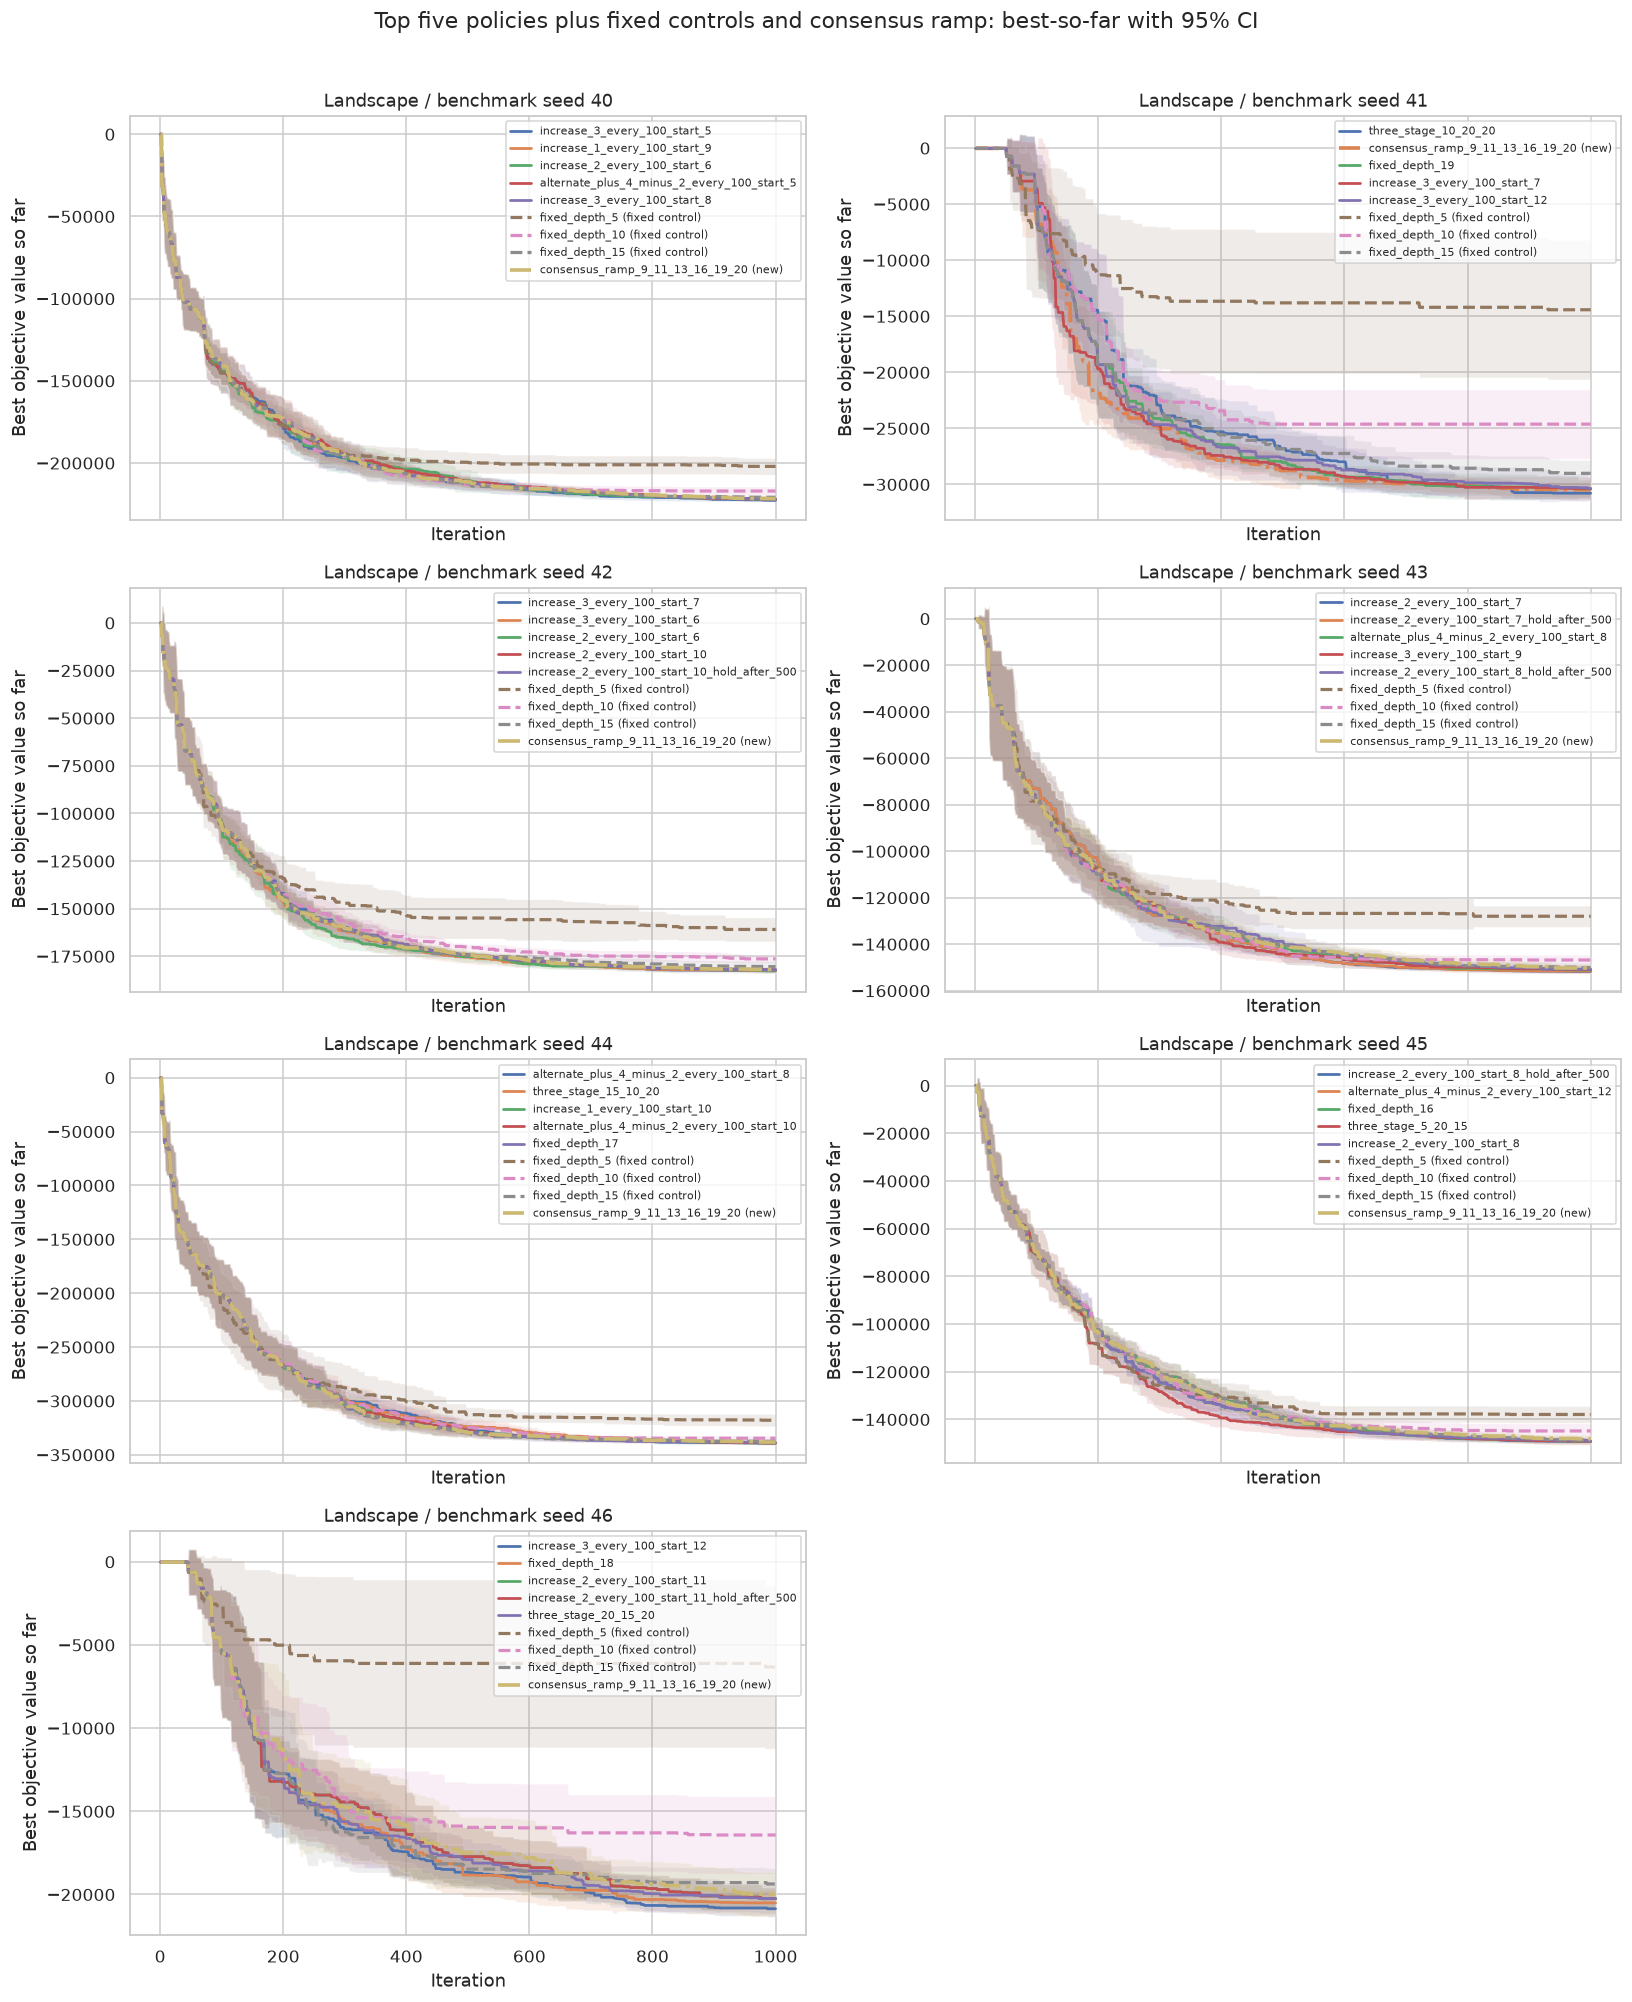

In [4]:

def mean_ci(matrix, confidence=0.95):
    matrix = np.asarray(matrix, dtype=float)
    mean = matrix.mean(axis=0)
    if matrix.shape[0] < 2:
        return mean, mean, mean
    sem = matrix.std(axis=0, ddof=1) / np.sqrt(matrix.shape[0])
    half = t.ppf((1 + confidence) / 2, df=matrix.shape[0] - 1) * sem
    return mean, mean - half, mean + half

fig, axes = plt.subplots(4, 2, figsize=(15, 18), sharex=True)
axes = axes.ravel()
for ax, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    top_selected = (landscape_policy.query('benchmark_seed == @benchmark_seed')
                    .nsmallest(TOP_CURVES, 'mean_final_regret').policy.tolist())
    selected = list(dict.fromkeys(top_selected + FIXED_CURVE_CONTROLS + [CONSENSUS_POLICY]))
    selected = [policy for policy in selected if (benchmark_seed, SMAC_SEEDS[0], policy) in curves]
    for policy in selected:
        matrix = np.stack([curves[(benchmark_seed, smac_seed, policy)] for smac_seed in SMAC_SEEDS])
        mean, lower, upper = mean_ci(matrix)
        iterations = np.arange(1, len(mean) + 1)
        is_fixed_control = policy in FIXED_CURVE_CONTROLS
        is_consensus = policy == CONSENSUS_POLICY
        label = policy
        if is_fixed_control:
            label = f'{policy} (fixed control)'
        elif is_consensus:
            label = f'{policy} (new)'
        ax.plot(iterations, mean, lw=2.4 if is_consensus else (2.1 if is_fixed_control else 1.8),
                linestyle='-.' if is_consensus else ('--' if is_fixed_control else '-'), label=label)
        ax.fill_between(iterations, lower, upper, alpha=0.16 if is_consensus else 0.14)
    ax.set_title(f'Landscape / benchmark seed {benchmark_seed}')
    ax.set_ylabel('Best objective value so far')
    ax.legend(fontsize=7, loc='best')
axes[-1].axis('off')
for ax in axes[:-1]:
    ax.set_xlabel('Iteration')
fig.suptitle('Top five policies plus fixed controls and consensus ramp: best-so-far with 95% CI', y=1.01)
fig.tight_layout()
plt.show()


## Three-stage depth choices among top policies

The 40 `(25%, 66%)` policies are ranked separately inside every benchmark-seed x SMAC-seed run. This gives 70 independent rankings and avoids averaging away SMAC-seed variability. Counts below answer how often each depth was chosen in each stage by the run-level top 5 and top 15.

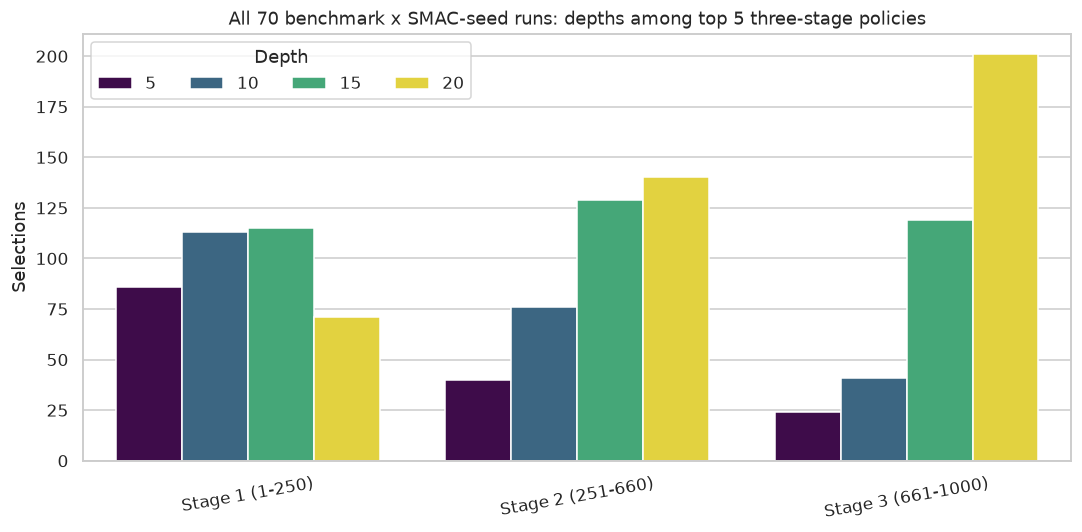

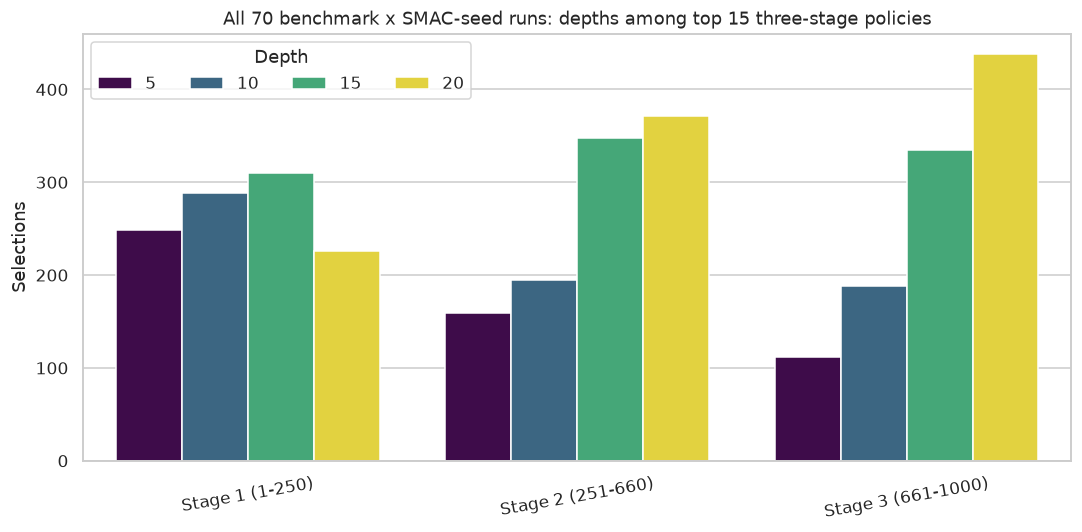

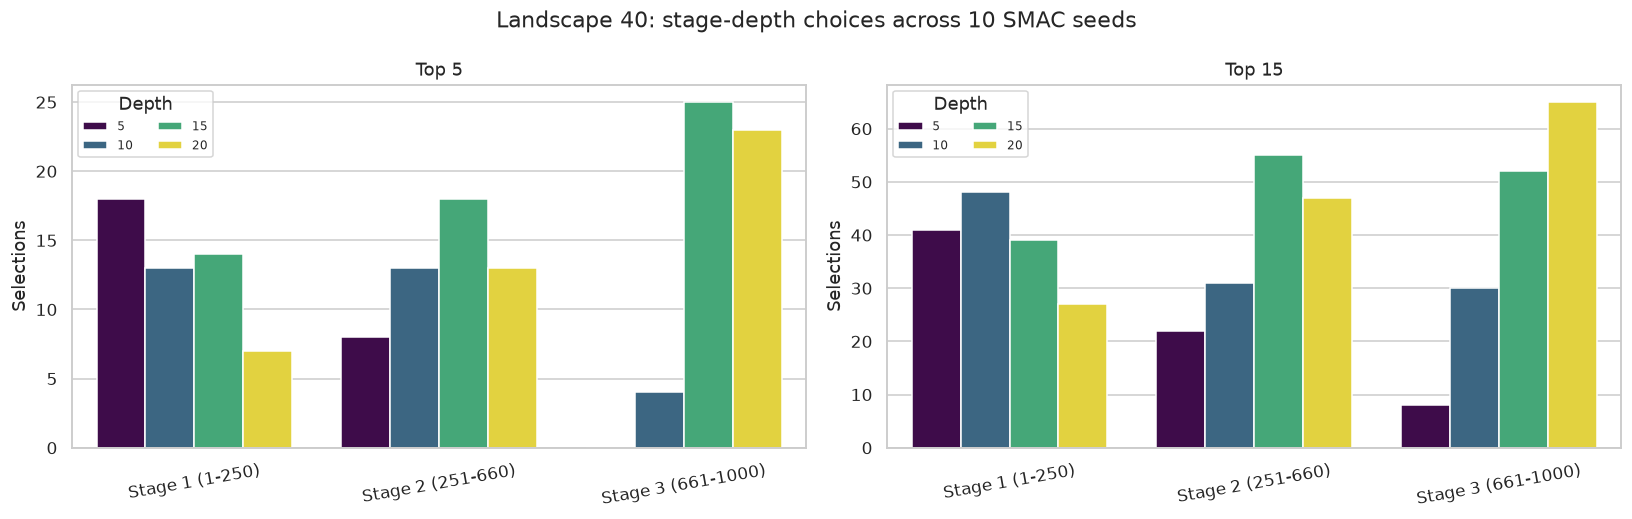

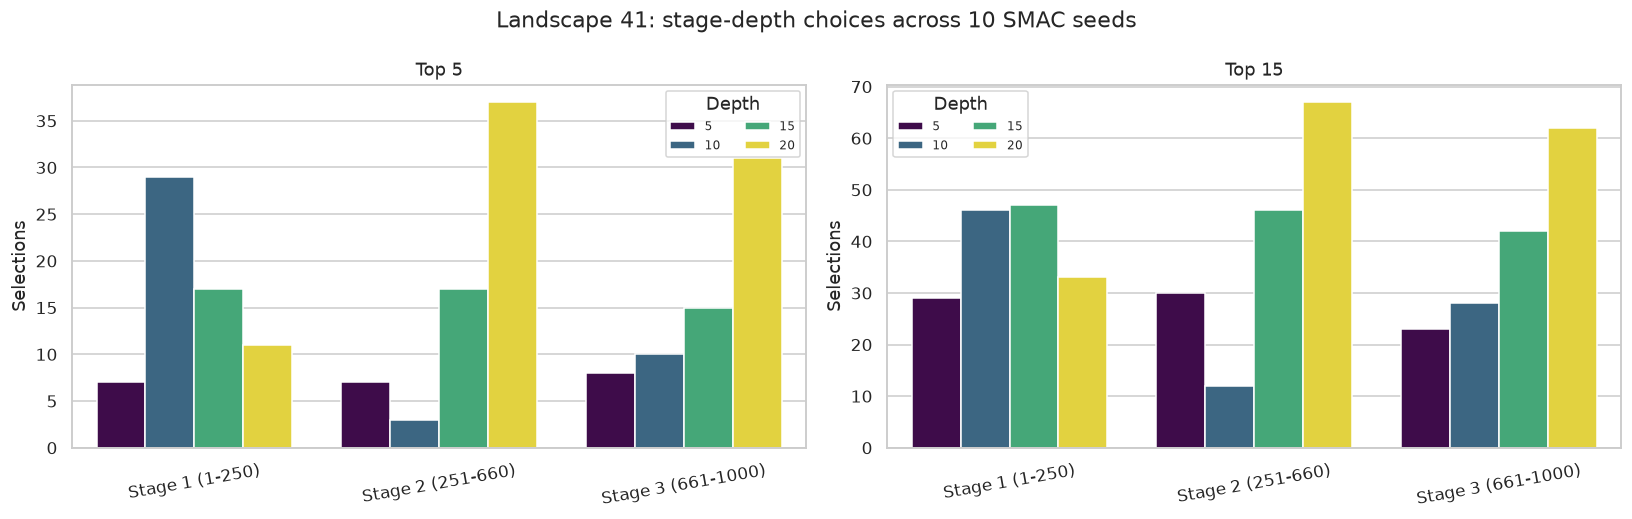

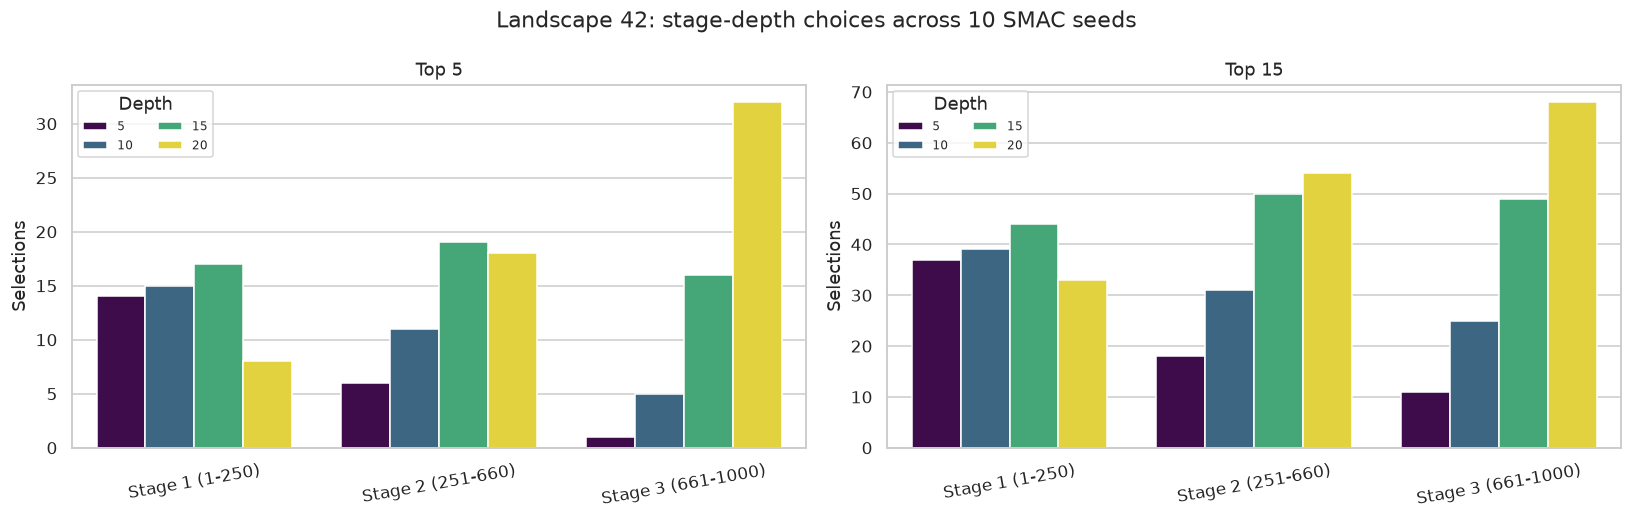

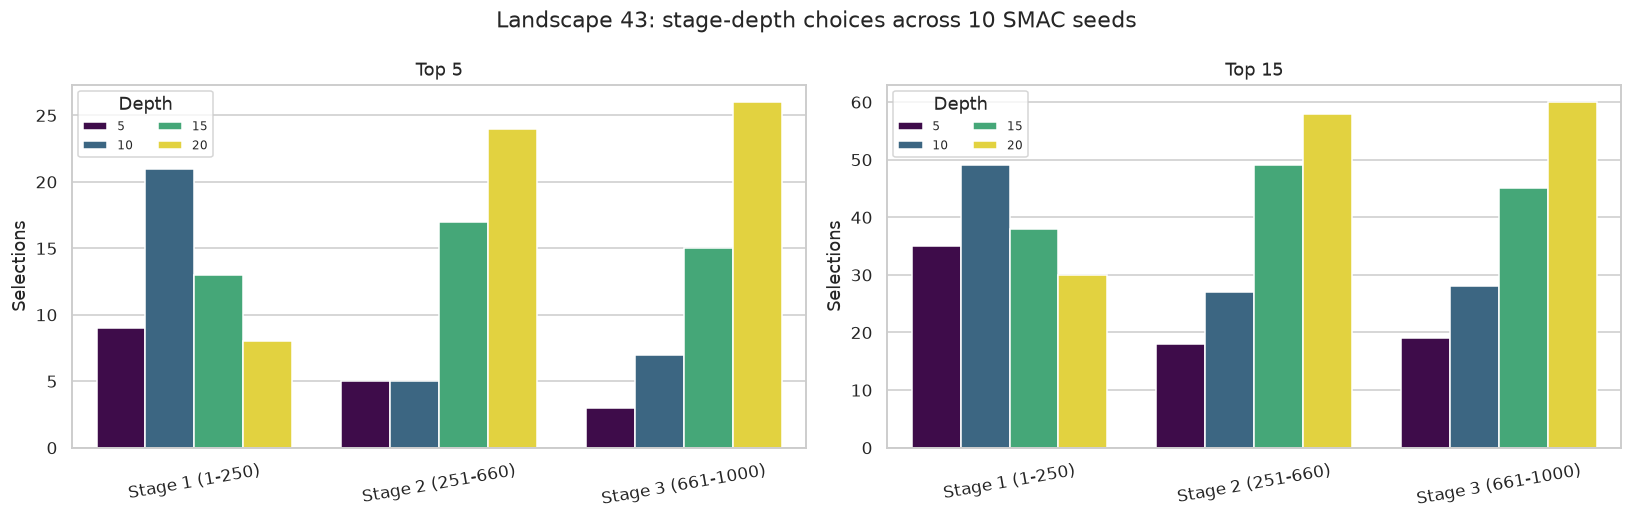

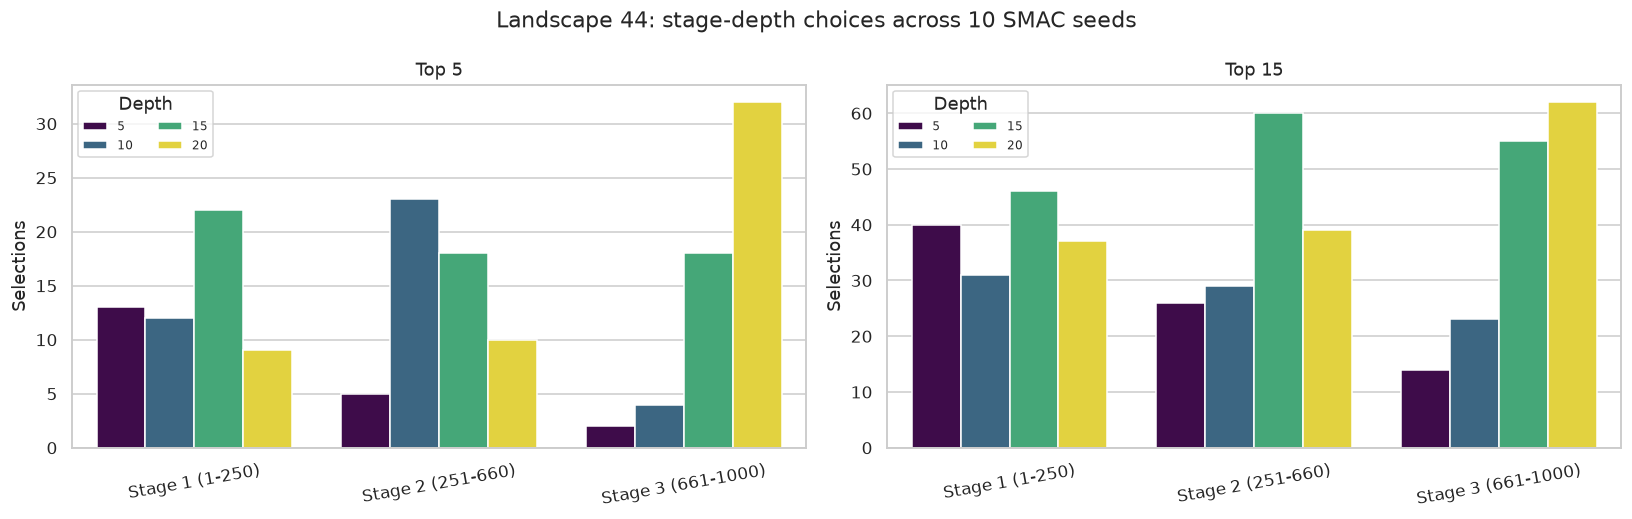

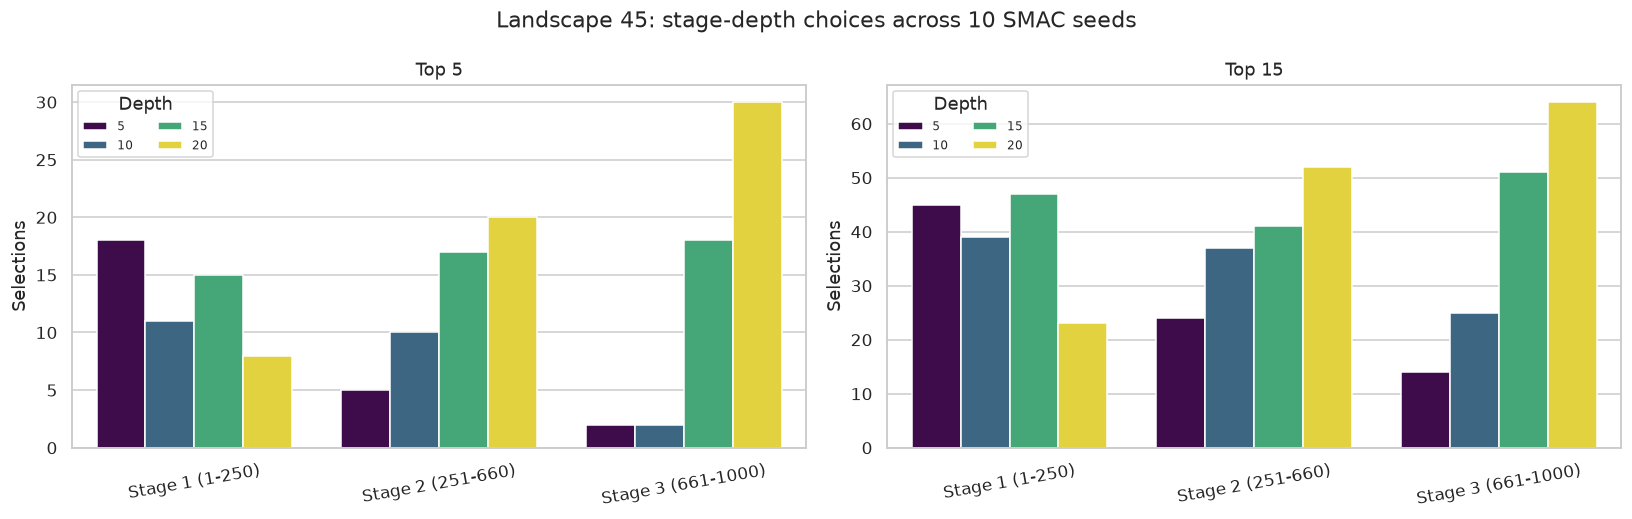

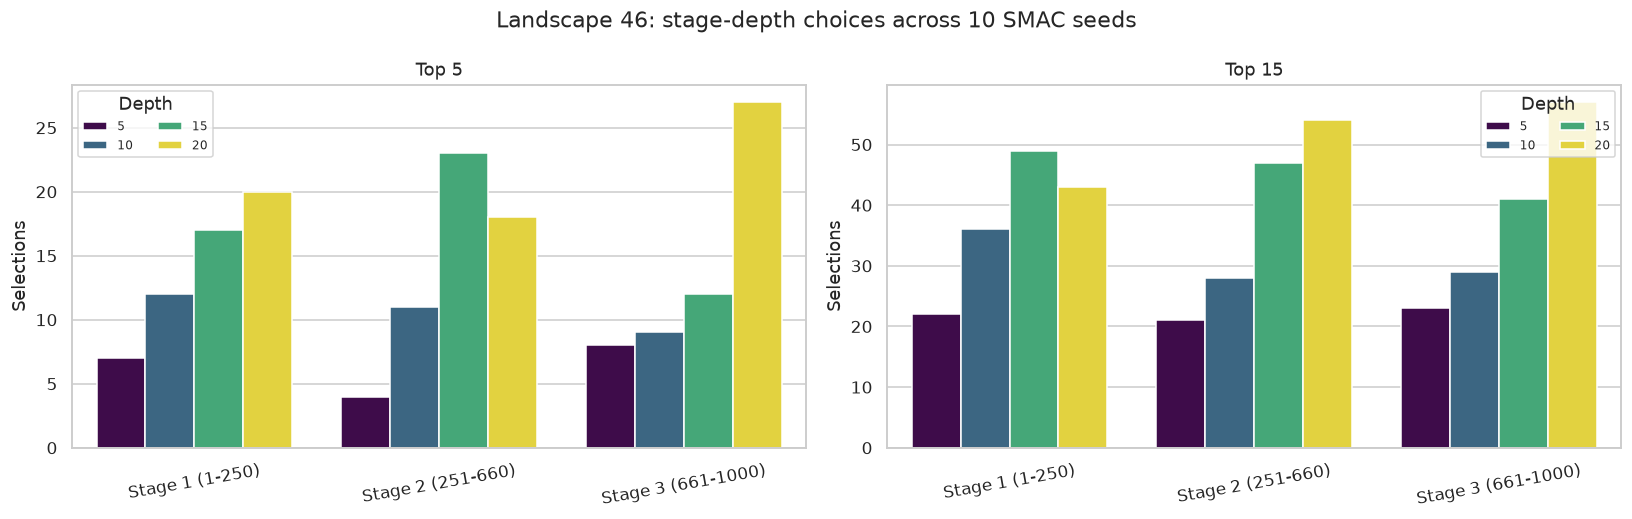

In [5]:
three_stage = results.query("policy_family == 'sampled_three_stage'").copy()
assert len(three_stage) == 7 * 10 * 40
three_stage['run_rank'] = three_stage.groupby(['benchmark_seed', 'smac_seed'])['final_regret'].rank(method='min')
stage_long = three_stage.melt(
    id_vars=['benchmark_seed', 'smac_seed', 'policy', 'final_regret', 'run_rank'],
    value_vars=['d1', 'd2', 'd3'], var_name='stage_code', value_name='depth')
stage_name = dict(zip(('d1', 'd2', 'd3'), STAGE_LABELS))
stage_long['stage'] = pd.Categorical(stage_long.stage_code.map(stage_name), categories=STAGE_LABELS, ordered=True)
stage_long['depth'] = stage_long.depth.astype(int)

def depth_frequency(data, top_n):
    index = pd.MultiIndex.from_product([STAGE_LABELS, STAGE_DEPTHS], names=['stage', 'depth'])
    return (data.query('run_rank <= @top_n').groupby(['stage', 'depth'], observed=False).size()
            .reindex(index, fill_value=0).rename('count').reset_index())

def plot_depth_frequency(data, top_n, ax, title):
    freq = depth_frequency(data, top_n)
    sns.barplot(data=freq, x='stage', y='count', hue='depth', hue_order=STAGE_DEPTHS, palette='viridis', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Selections')
    ax.tick_params(axis='x', rotation=10)
    return freq

global_frequencies = {}
for top_n in (5, 15):
    fig, ax = plt.subplots(figsize=(10, 5))
    global_frequencies[top_n] = plot_depth_frequency(
        stage_long, top_n, ax, f'All 70 benchmark x SMAC-seed runs: depths among top {top_n} three-stage policies')
    ax.legend(title='Depth', ncol=4)
    fig.tight_layout()
    plt.show()

for benchmark_seed in BENCHMARK_SEEDS:
    subset = stage_long.query('benchmark_seed == @benchmark_seed')
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
    for ax, top_n in zip(axes, (5, 15)):
        plot_depth_frequency(subset, top_n, ax, f'Top {top_n}')
        ax.legend(title='Depth', ncol=2, fontsize=8)
    fig.suptitle(f'Landscape {benchmark_seed}: stage-depth choices across 10 SMAC seeds')
    fig.tight_layout()
    plt.show()

## Policy rank conditional on the depth used in each stage

Each observation is a policy's rank among the 40 three-stage policies for one landscape and SMAC seed. Lower ranks are better. The first figure pools all landscapes; the following seven figures retain each landscape separately.

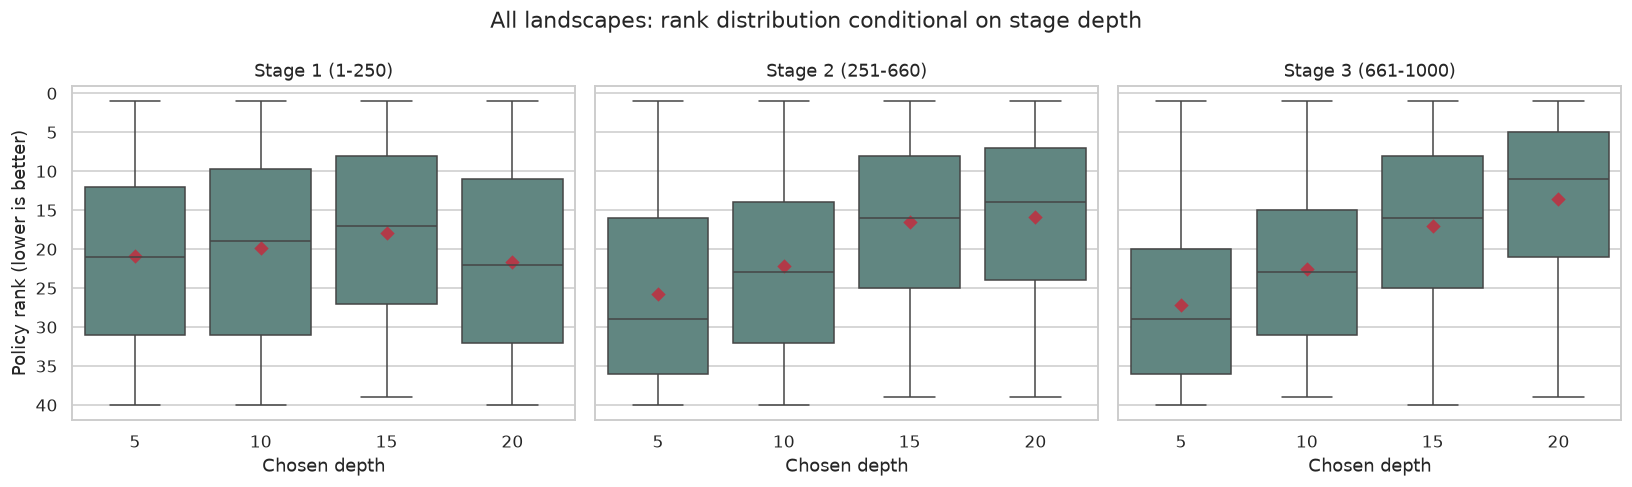

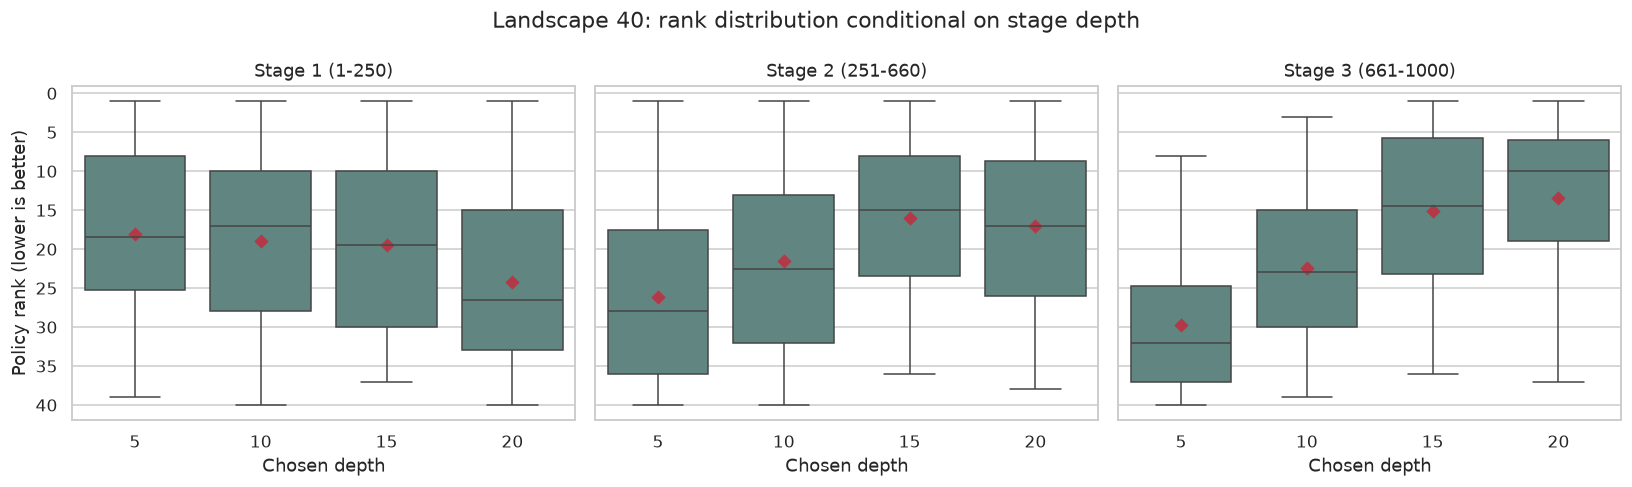

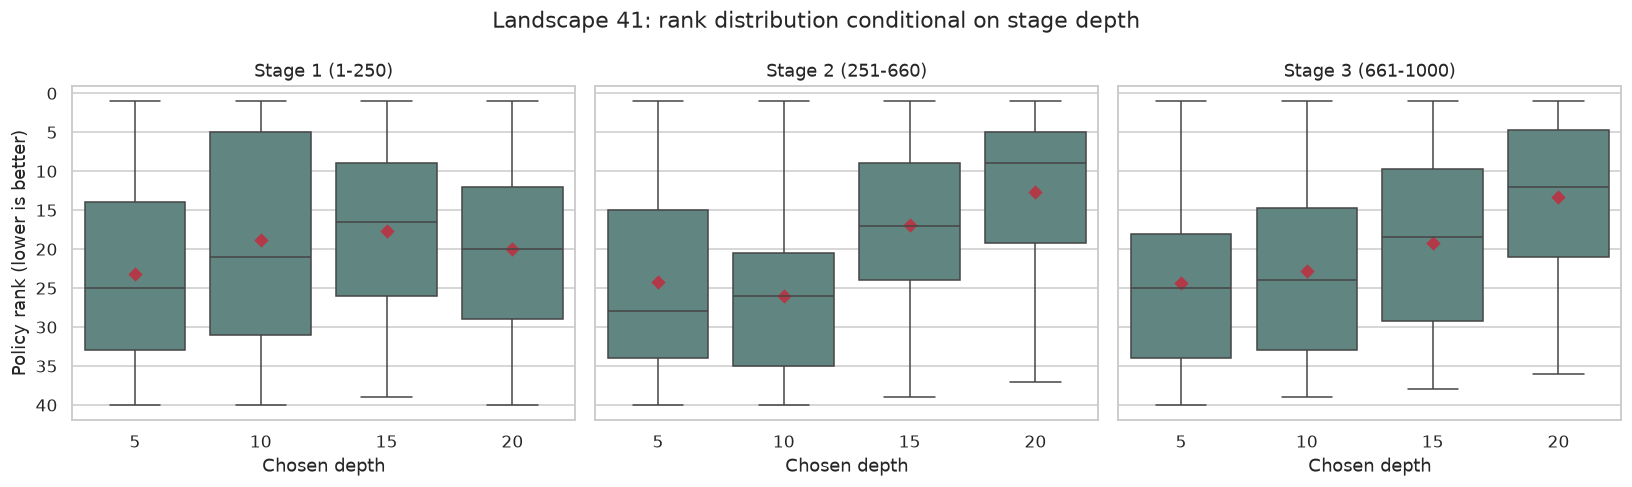

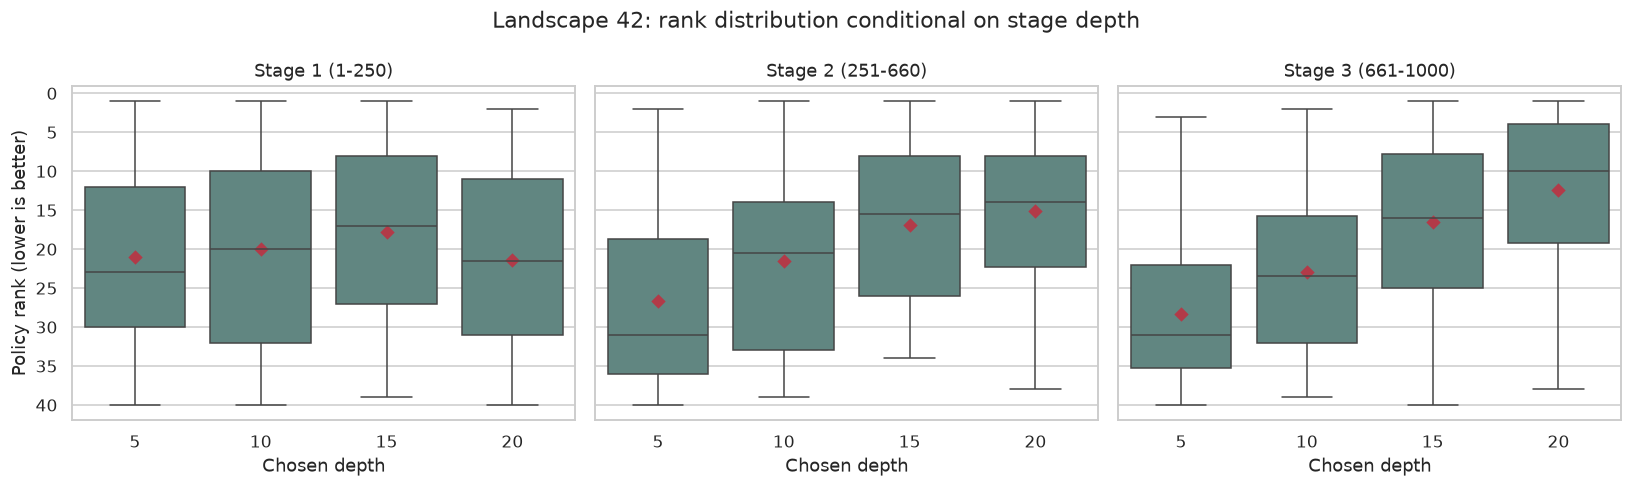

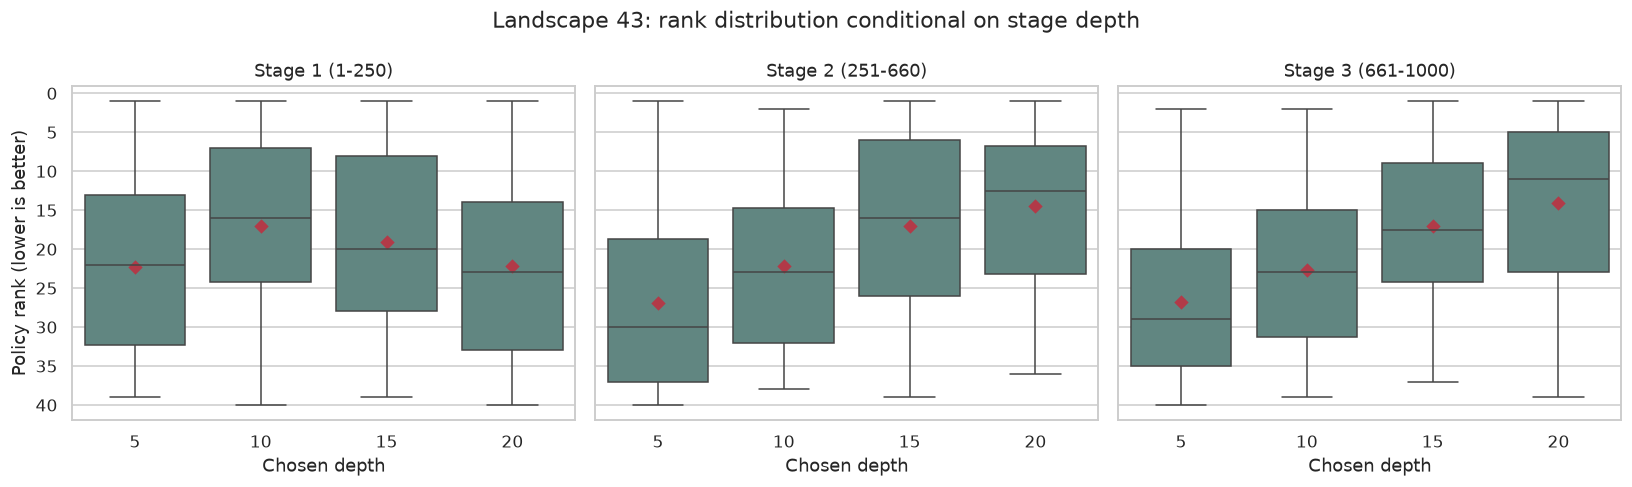

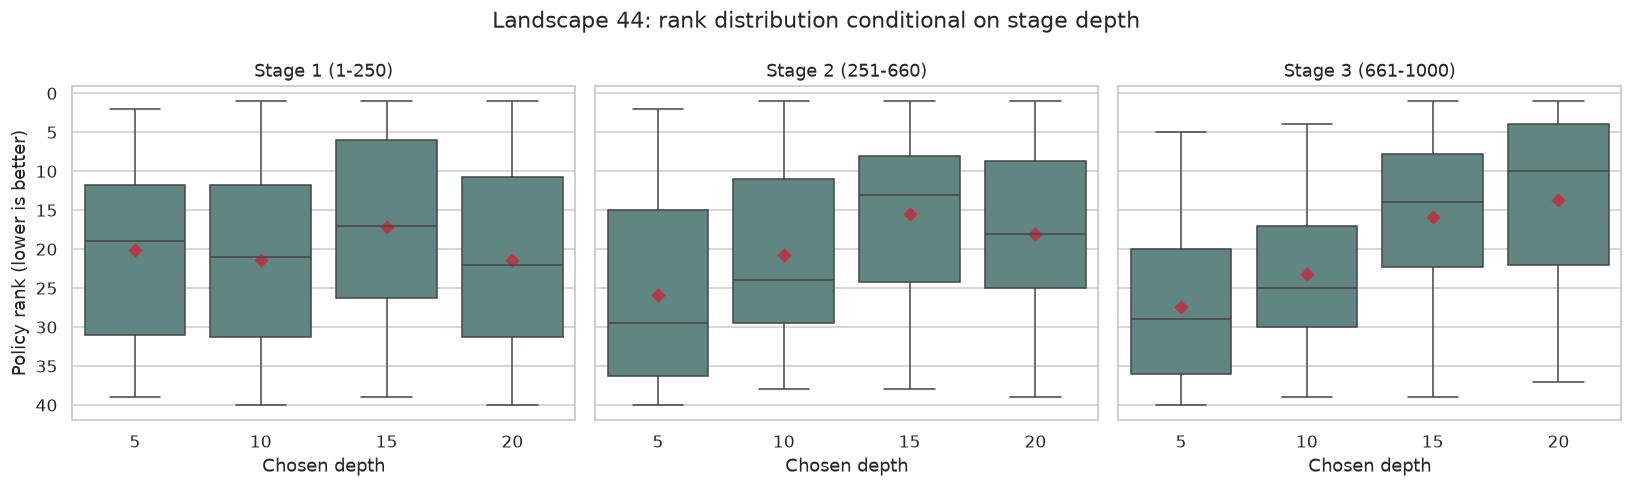

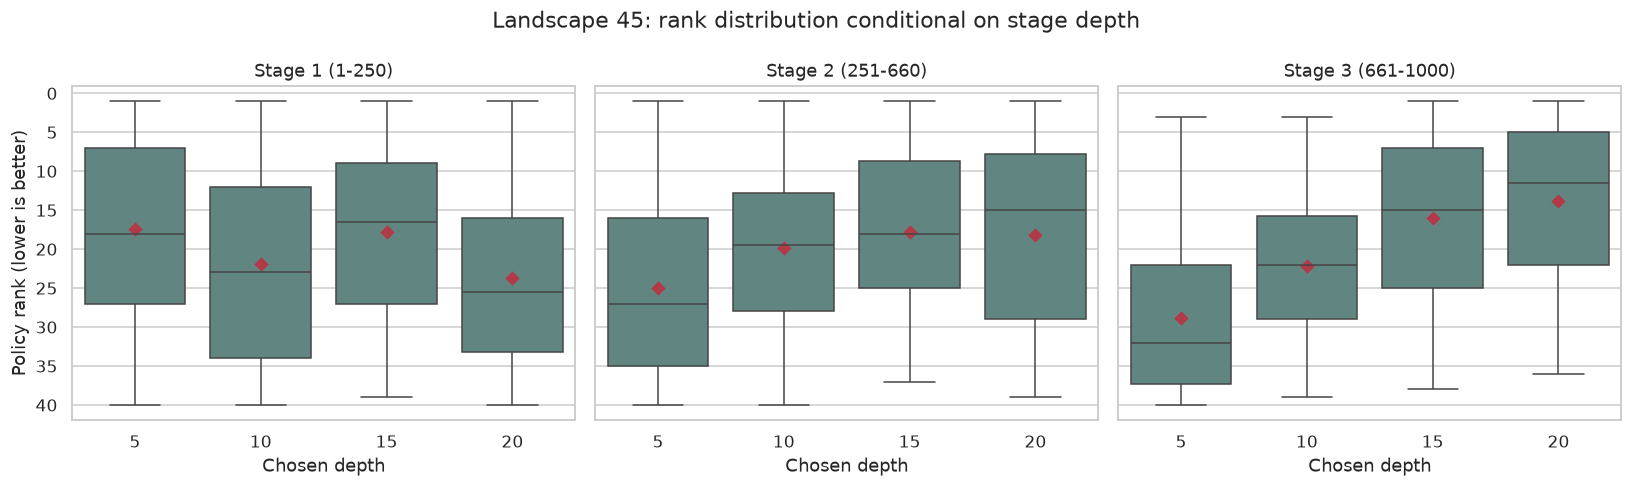

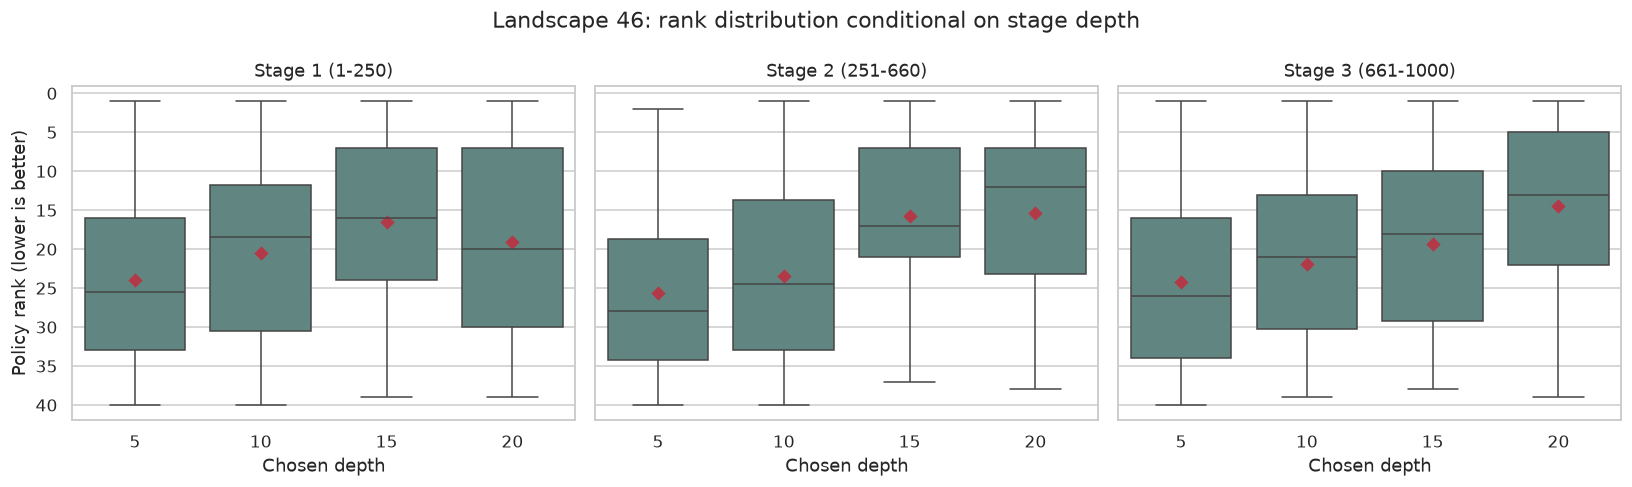

In [6]:
def plot_rank_boxes(data, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, stage in zip(axes, STAGE_LABELS):
        subset = data[data.stage == stage]
        sns.boxplot(data=subset, x='depth', y='run_rank', order=STAGE_DEPTHS, color='#5b8c85', ax=ax, showfliers=False)
        sns.pointplot(data=subset, x='depth', y='run_rank', order=STAGE_DEPTHS, color='#b23a48', errorbar=None,
                      markers='D', linestyles='none', markersize=5, ax=ax)
        ax.set_title(stage)
        ax.set_xlabel('Chosen depth')
        ax.set_ylabel('Policy rank (lower is better)' if ax is axes[0] else '')
        ax.invert_yaxis()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_rank_boxes(stage_long, 'All landscapes: rank distribution conditional on stage depth')
for benchmark_seed in BENCHMARK_SEEDS:
    plot_rank_boxes(stage_long.query('benchmark_seed == @benchmark_seed'),
                    f'Landscape {benchmark_seed}: rank distribution conditional on stage depth')

## Leave-one-landscape-out validation

For each held-out landscape, policies are selected using only the other six landscapes. Because regret scales can differ by landscape, selection minimizes mean within-landscape rank rather than raw regret.

The comparison includes five strategies:

- **Top-1 / Top-3 / Top-5 adaptive portfolios:** the SMAC-seed-matched mean performance of the best 1, 3, or 5 adaptive policies selected on the six training landscapes.
- **LOO best fixed:** the fixed depth with the best mean training-landscape rank.
- **Oracle fixed:** the best fixed depth selected directly on the held-out landscape (an optimistic reference, not a deployable method).

For every held-out landscape, the trajectory plot shows mean best-so-far performance with pointwise 95% Student-t confidence intervals across the ten SMAC seeds. The portfolio trajectory for each seed is the mean of its selected policies' trajectories. Seed-level boxplots additionally show the final-regret distribution.


,held_out_landscape,top_1_adaptive,top_3_adaptive,top_5_adaptive,loo_best_fixed,oracle_fixed,loo_fixed_training_rank
0,40,increase_3_every_100_start_7,increase_3_every_100_start_7; alternate_plus_4...,increase_3_every_100_start_7; alternate_plus_4...,fixed_depth_17,fixed_depth_20,20.833333
1,41,increase_3_every_100_start_7,increase_3_every_100_start_7; increase_2_every...,increase_3_every_100_start_7; increase_2_every...,fixed_depth_18,fixed_depth_19,24.333333
2,42,three_stage_10_20_20,three_stage_10_20_20; increase_3_every_100_sta...,three_stage_10_20_20; increase_3_every_100_sta...,fixed_depth_17,fixed_depth_18,22.500000
3,43,alternate_plus_4_minus_2_every_100_start_11,alternate_plus_4_minus_2_every_100_start_11; i...,alternate_plus_4_minus_2_every_100_start_11; i...,fixed_depth_18,fixed_depth_19,21.333333
4,44,three_stage_10_20_20,three_stage_10_20_20; increase_3_every_100_sta...,three_stage_10_20_20; increase_3_every_100_sta...,fixed_depth_20,fixed_depth_17,22.166667
5,45,increase_3_every_100_start_7,increase_3_every_100_start_7; consensus_ramp_9...,increase_3_every_100_start_7; consensus_ramp_9...,fixed_depth_18,fixed_depth_16,17.333333
6,46,increase_3_every_100_start_7,increase_3_every_100_start_7; consensus_ramp_9...,increase_3_every_100_start_7; consensus_ramp_9...,fixed_depth_20,fixed_depth_18,22.916667


,held_out_landscape,strategy,mean_final_regret,std,n,median_final_regret,mean_relative_to_oracle,ci95
1,40,Oracle fixed,4138.233385,1194.070329,10,4159.200839,1.000000,854.186456
4,40,Top-5 adaptive portfolio,4336.835314,942.489561,10,4219.323387,1.070355,674.216416
2,40,Top-1 adaptive portfolio,4357.957015,1063.842404,10,4376.748381,1.075669,761.027011
3,40,Top-3 adaptive portfolio,4471.315062,1137.396082,10,4607.986583,1.103713,813.644142
0,40,LOO best fixed,4992.249215,1272.635173,10,4612.500575,1.244531,910.388360
6,41,Oracle fixed,2220.708674,1121.025478,10,1984.833074,1.000000,801.933318
7,41,Top-1 adaptive portfolio,2232.357223,1391.398783,10,1991.548095,1.135829,995.346728
5,41,LOO best fixed,2701.080589,989.886114,10,2207.277291,1.356658,708.121868
8,41,Top-3 adaptive portfolio,2724.767647,921.370046,10,2514.138169,1.379071,659.108425
9,41,Top-5 adaptive portfolio,2835.428695,797.089113,10,2769.785852,1.485127,570.203202


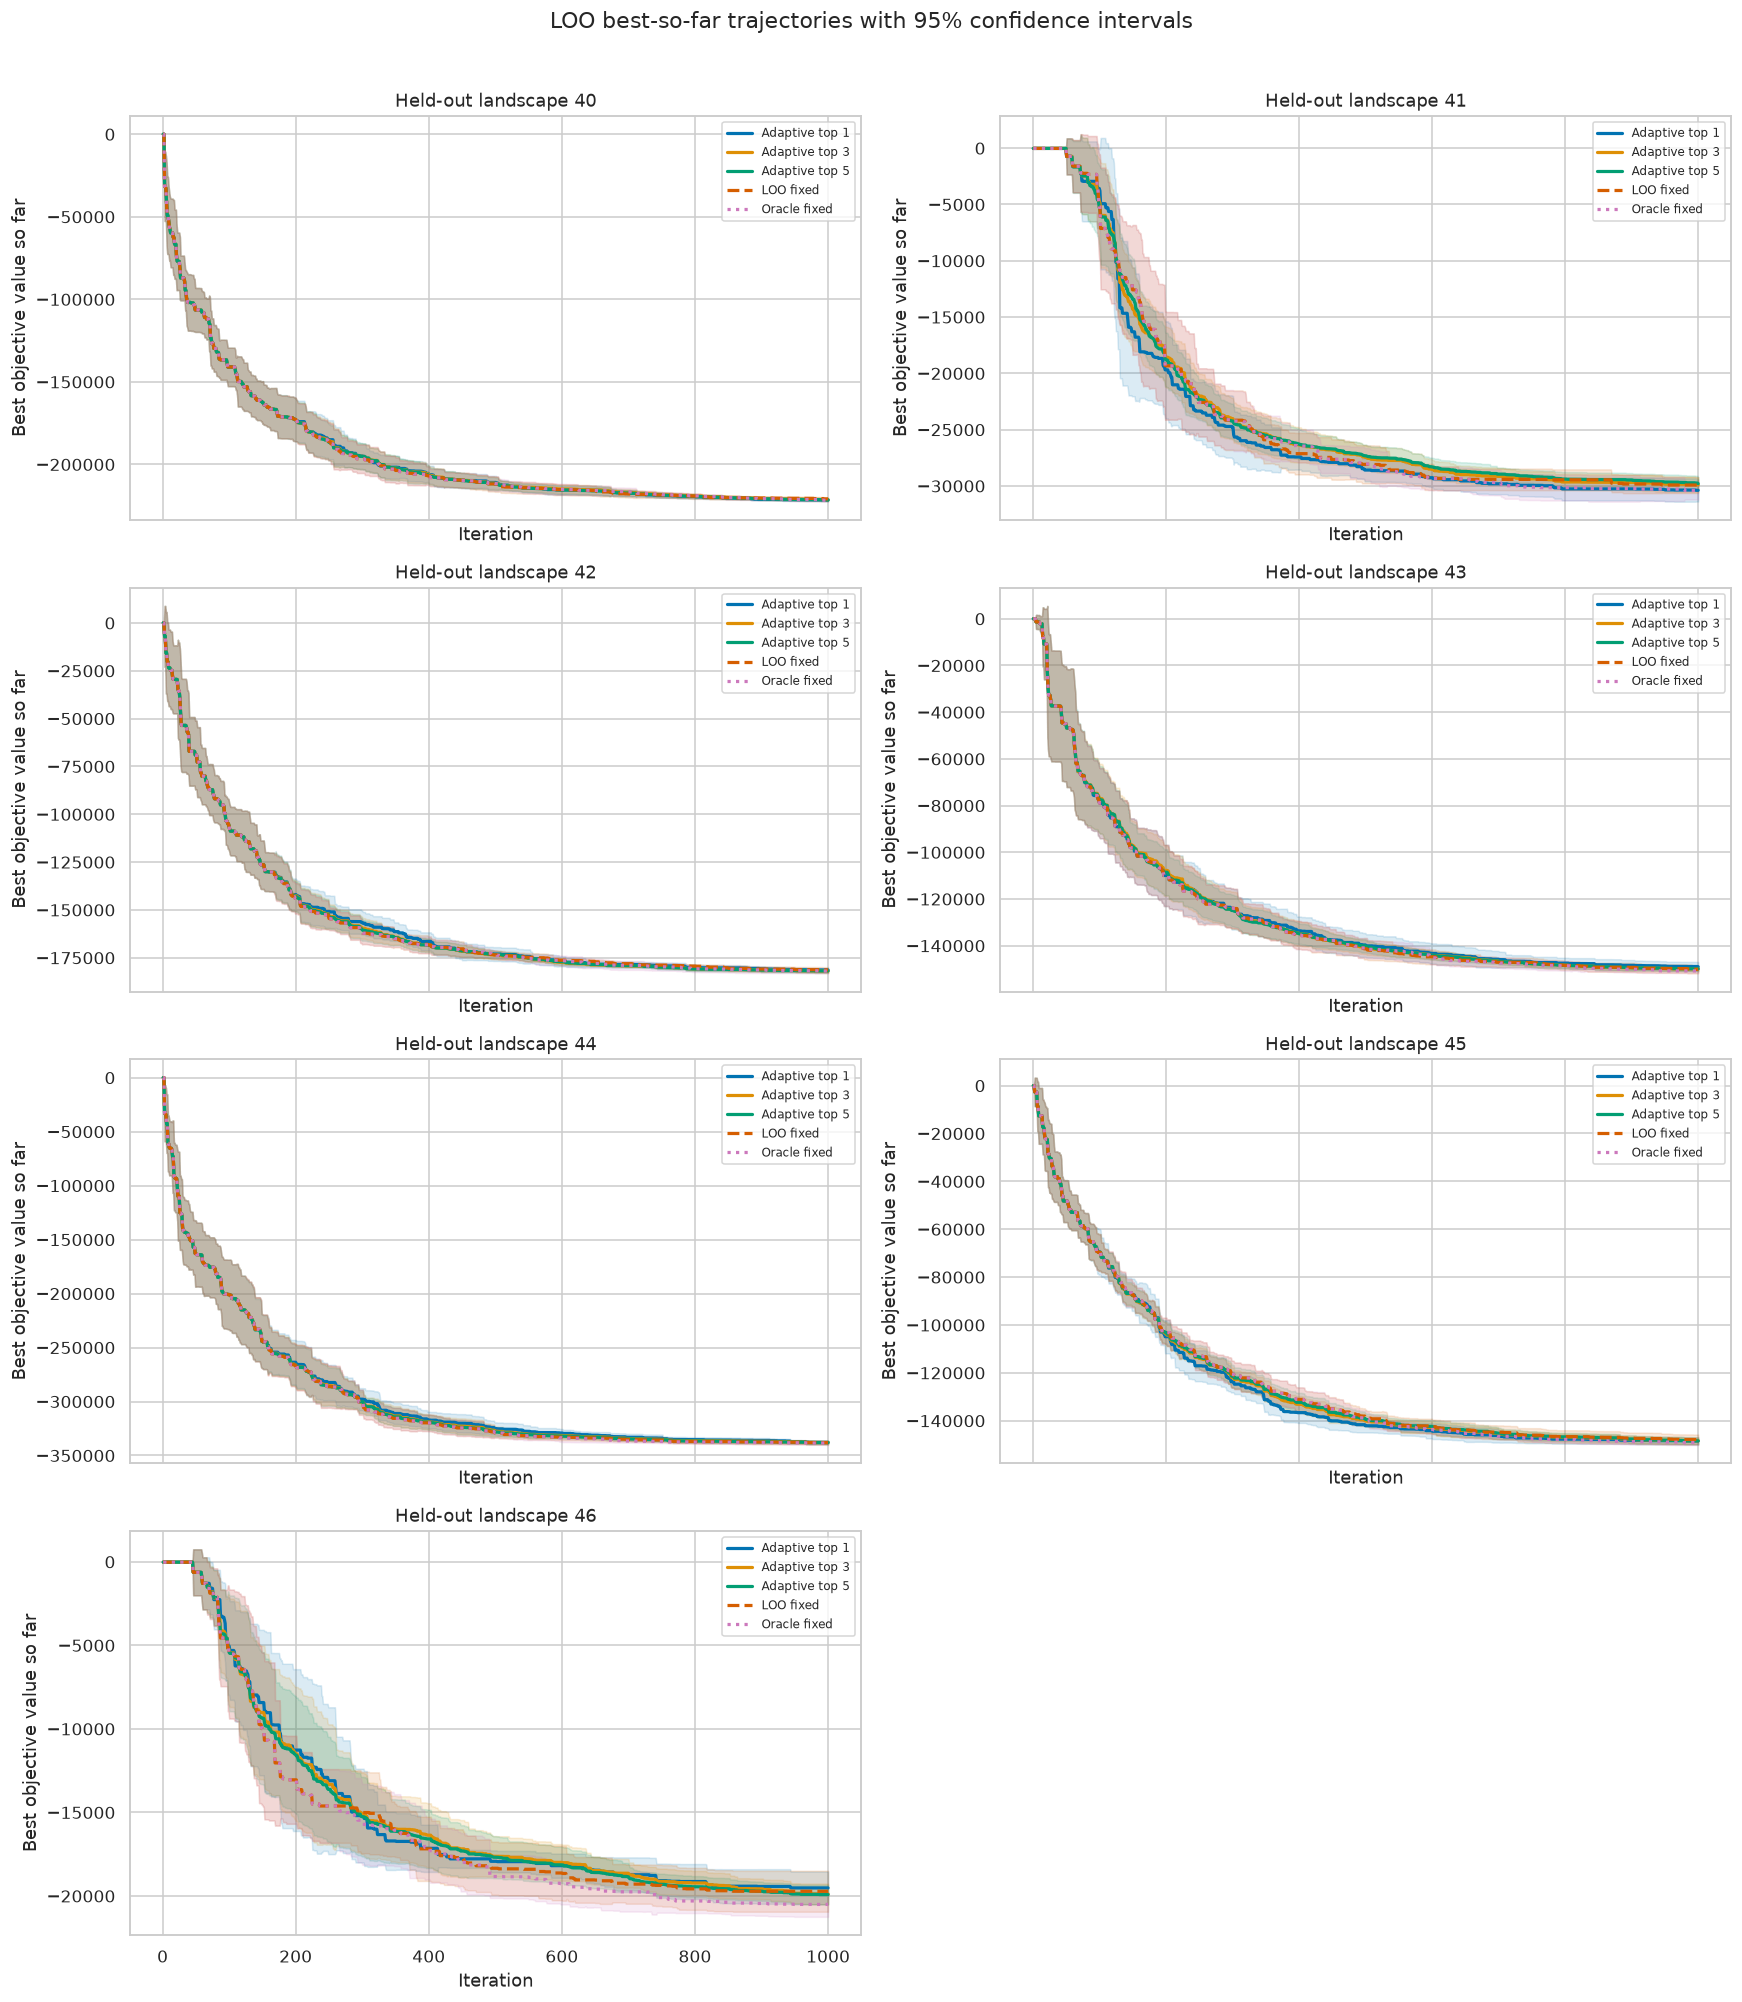

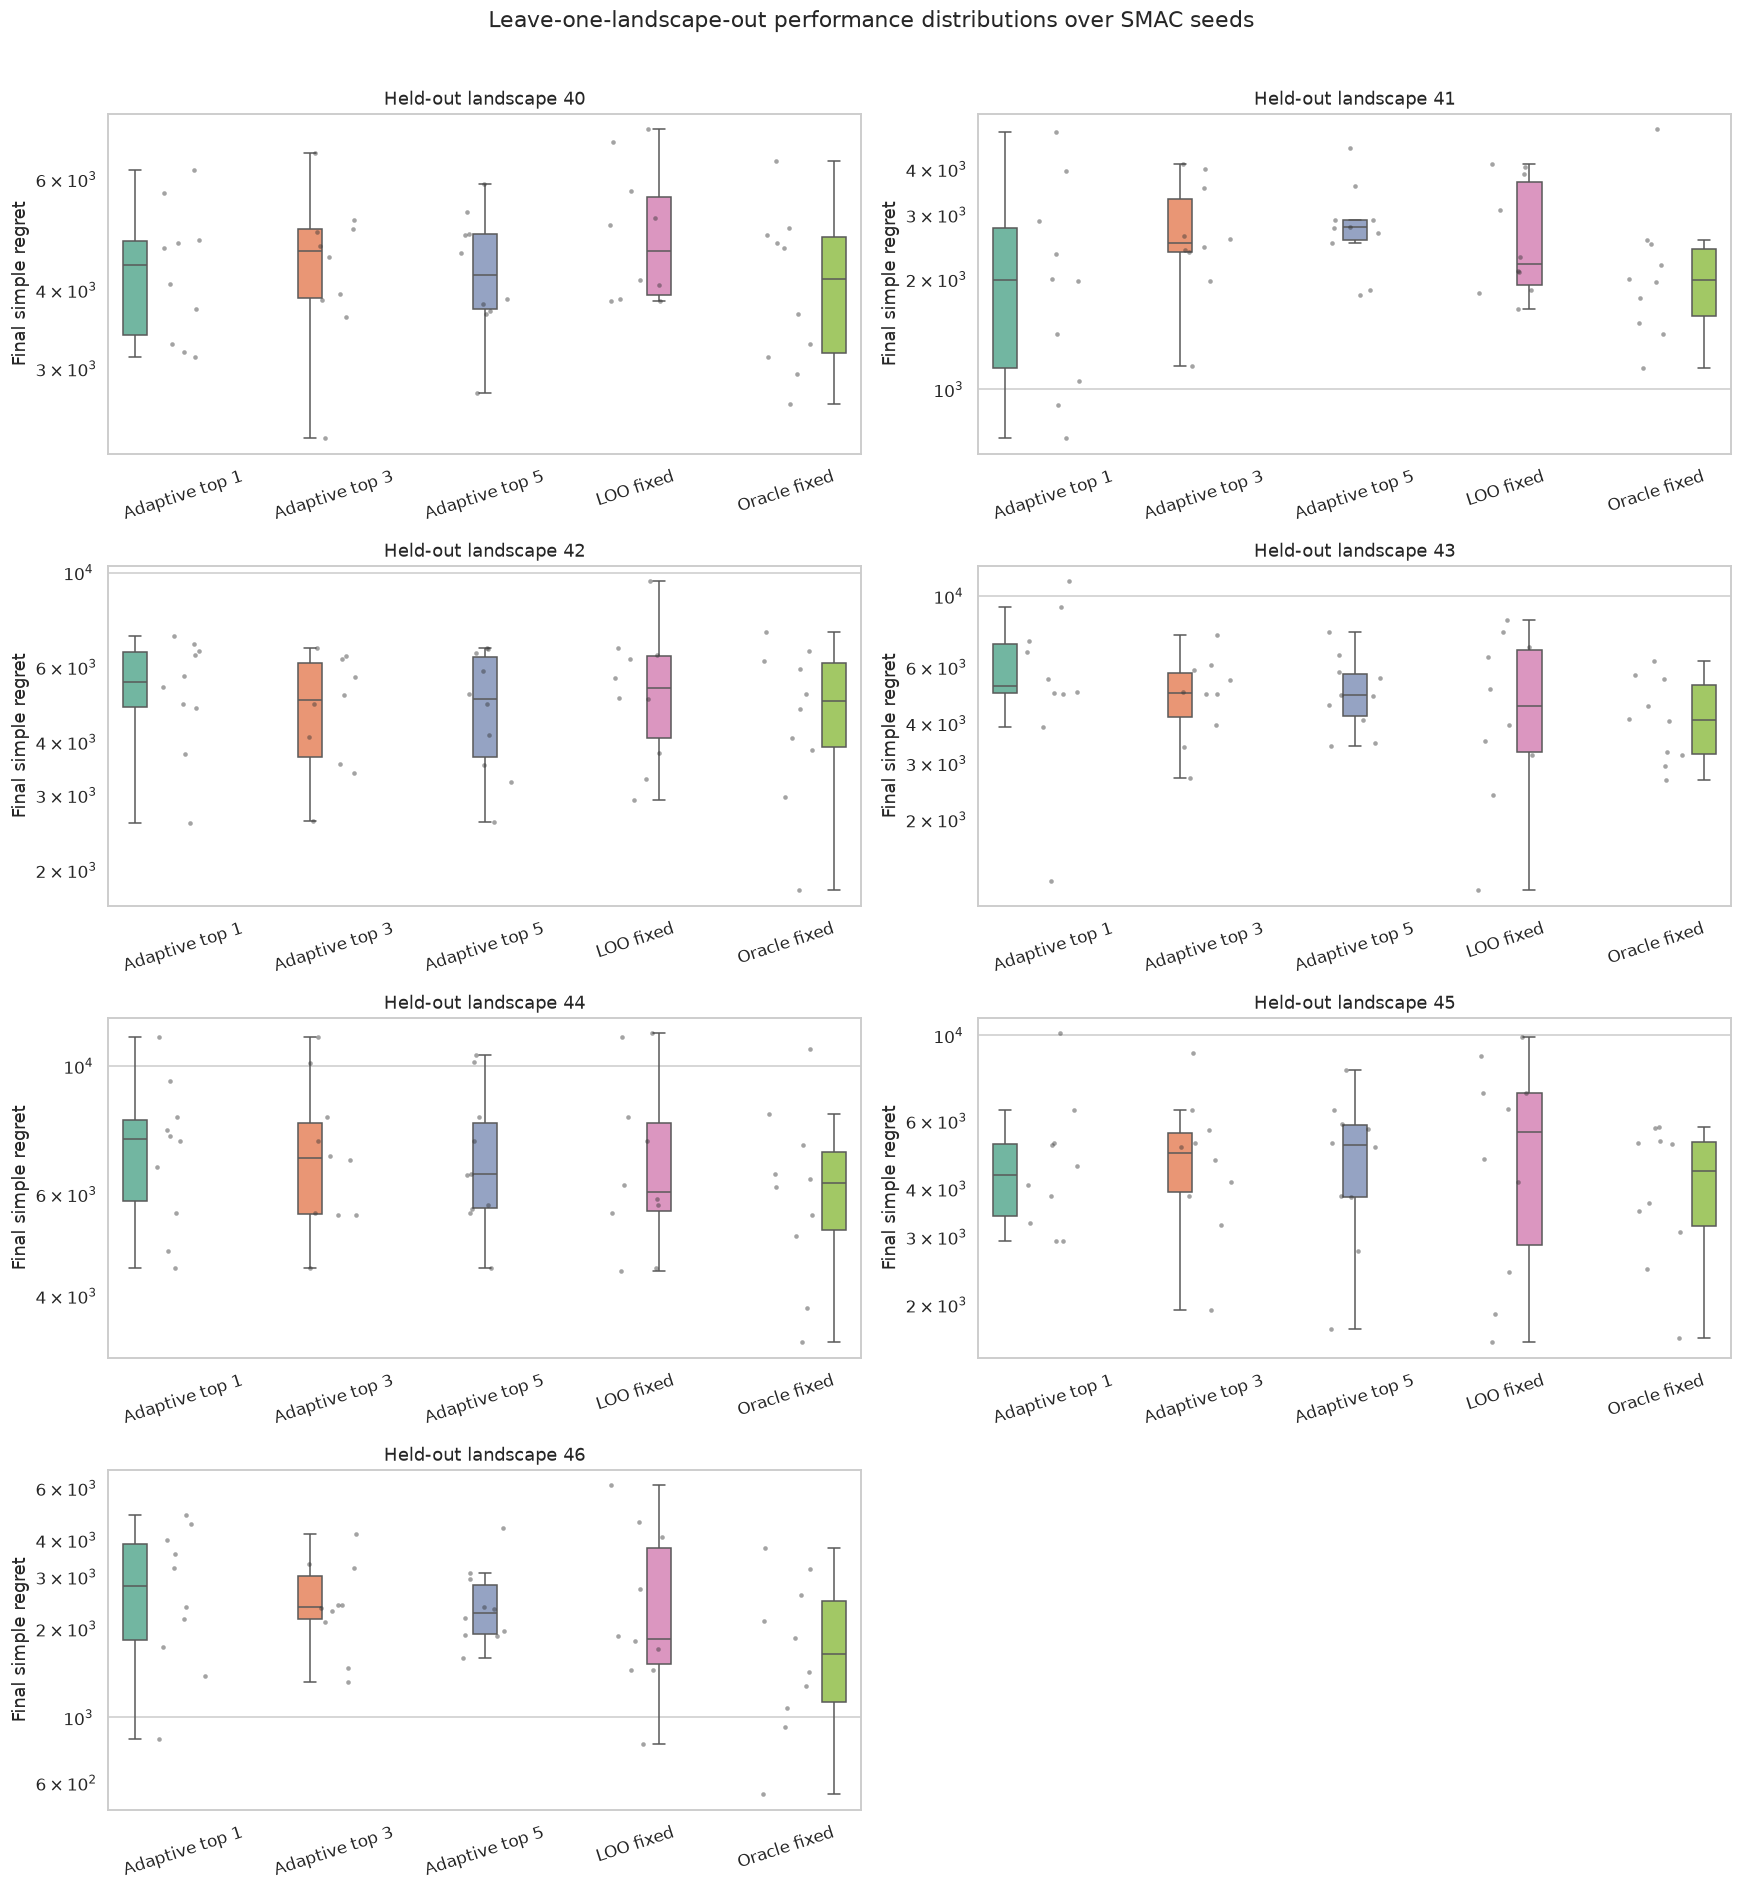

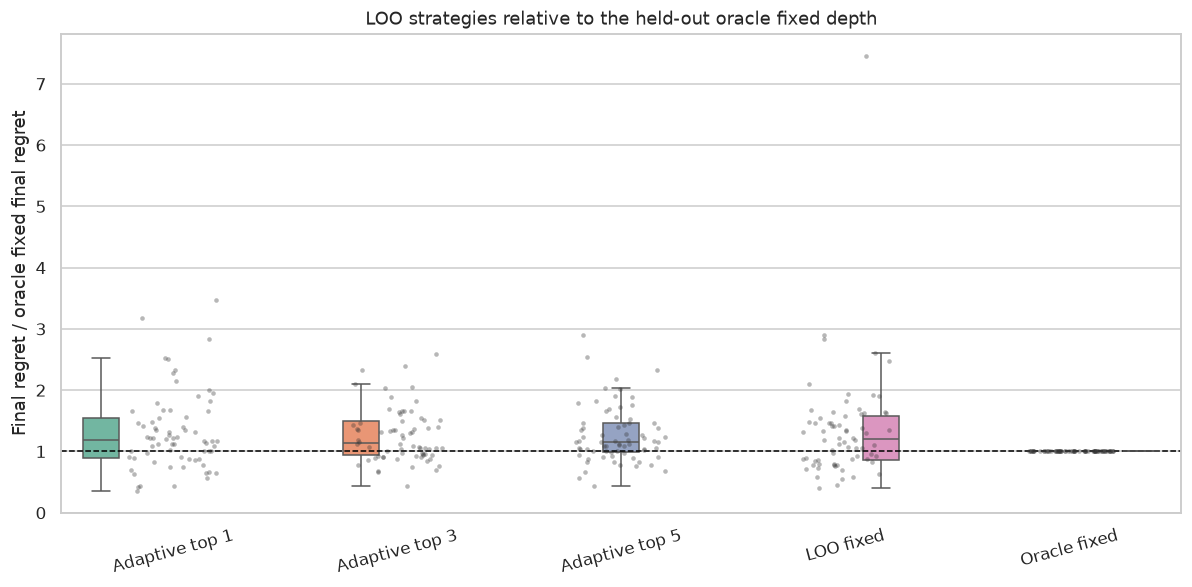

In [7]:

selection_rows = []
evaluation_rows = []
loo_policy_choices = {}

for held_out in BENCHMARK_SEEDS:
    training = landscape_policy.query('benchmark_seed != @held_out').copy()
    training['training_landscape_rank'] = training.groupby('benchmark_seed')['mean_final_regret'].rank(method='average')
    aggregate = (training.groupby(['policy', 'policy_family', 'policy_type', 'is_adaptive'], as_index=False)
                 .agg(mean_training_rank=('training_landscape_rank', 'mean'),
                      mean_training_regret=('mean_final_regret', 'mean')))
    adaptive_ranked = aggregate.query('is_adaptive').sort_values(['mean_training_rank', 'mean_training_regret', 'policy'])
    best_fixed = (aggregate.query('not is_adaptive').sort_values(['mean_training_rank', 'mean_training_regret', 'policy']).iloc[0])
    oracle_fixed = (landscape_policy.query('benchmark_seed == @held_out and not is_adaptive')
                    .sort_values(['mean_final_regret', 'policy']).iloc[0])
    selected_by_n = {top_n: adaptive_ranked.head(top_n).policy.tolist() for top_n in LOO_TOP_NS}
    loo_policy_choices[held_out] = {
        **{f'Top-{top_n} adaptive portfolio': policies for top_n, policies in selected_by_n.items()},
        'LOO best fixed': [best_fixed.policy],
        'Oracle fixed': [oracle_fixed.policy],
    }
    selection_rows.append({
        'held_out_landscape': held_out,
        'top_1_adaptive': '; '.join(selected_by_n[1]),
        'top_3_adaptive': '; '.join(selected_by_n[3]),
        'top_5_adaptive': '; '.join(selected_by_n[5]),
        'loo_best_fixed': best_fixed.policy,
        'oracle_fixed': oracle_fixed.policy,
        'loo_fixed_training_rank': best_fixed.mean_training_rank,
    })
    held_results = results.query('benchmark_seed == @held_out')
    for smac_seed in SMAC_SEEDS:
        seed_results = held_results.query('smac_seed == @smac_seed').set_index('policy')
        values = {
            **{f'Top-{top_n} adaptive portfolio': seed_results.loc[policies, 'final_regret'].mean()
               for top_n, policies in selected_by_n.items()},
            'LOO best fixed': seed_results.loc[best_fixed.policy, 'final_regret'],
            'Oracle fixed': seed_results.loc[oracle_fixed.policy, 'final_regret'],
        }
        oracle_value = float(seed_results.loc[oracle_fixed.policy, 'final_regret'])
        for strategy, value in values.items():
            evaluation_rows.append({
                'held_out_landscape': held_out,
                'smac_seed': smac_seed,
                'strategy': strategy,
                'final_regret': float(value),
                'relative_to_oracle_fixed': float(value) / oracle_value,
            })

loo_selection = pd.DataFrame(selection_rows)
loo_evaluation = pd.DataFrame(evaluation_rows)
display(loo_selection)

strategy_order = [
    'Top-1 adaptive portfolio',
    'Top-3 adaptive portfolio',
    'Top-5 adaptive portfolio',
    'LOO best fixed',
    'Oracle fixed',
]
short_strategy_labels = {
    'Top-1 adaptive portfolio': 'Adaptive top 1',
    'Top-3 adaptive portfolio': 'Adaptive top 3',
    'Top-5 adaptive portfolio': 'Adaptive top 5',
    'LOO best fixed': 'LOO fixed',
    'Oracle fixed': 'Oracle fixed',
}
loo_summary = (loo_evaluation.groupby(['held_out_landscape', 'strategy'], as_index=False)
               .agg(mean_final_regret=('final_regret', 'mean'), std=('final_regret', 'std'), n=('final_regret', 'size'),
                    median_final_regret=('final_regret', 'median'),
                    mean_relative_to_oracle=('relative_to_oracle_fixed', 'mean')))
loo_summary['ci95'] = t.ppf(0.975, loo_summary.n - 1) * loo_summary['std'] / np.sqrt(loo_summary.n)
display(loo_summary.sort_values(['held_out_landscape', 'mean_final_regret']))

fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True, sharey=False)
axes = axes.ravel()
loo_curve_palette = dict(zip(strategy_order, sns.color_palette('colorblind', len(strategy_order))))
loo_line_styles = {
    'Top-1 adaptive portfolio': '-',
    'Top-3 adaptive portfolio': '-',
    'Top-5 adaptive portfolio': '-',
    'LOO best fixed': '--',
    'Oracle fixed': ':',
}
for ax, held_out in zip(axes, BENCHMARK_SEEDS):
    for strategy in strategy_order:
        selected_policies = loo_policy_choices[held_out][strategy]
        seed_trajectories = []
        for smac_seed in SMAC_SEEDS:
            policy_trajectories = np.stack([
                curves[(held_out, smac_seed, policy)] for policy in selected_policies
            ])
            seed_trajectories.append(policy_trajectories.mean(axis=0))
        mean, lower, upper = mean_ci(np.stack(seed_trajectories))
        iterations = np.arange(1, len(mean) + 1)
        color = loo_curve_palette[strategy]
        ax.plot(iterations, mean, color=color, linestyle=loo_line_styles[strategy],
                lw=2.1, label=short_strategy_labels[strategy])
        ax.fill_between(iterations, lower, upper, color=color, alpha=0.14)
    ax.set_title(f'Held-out landscape {held_out}')
    ax.set_ylabel('Best objective value so far')
    ax.legend(fontsize=8, loc='best')
axes[-1].axis('off')
for ax in axes[:-1]:
    ax.set_xlabel('Iteration')
fig.suptitle('LOO best-so-far trajectories with 95% confidence intervals', y=1.01)
fig.tight_layout()
plt.show()

plot_data = loo_evaluation.copy()
plot_data['strategy_label'] = pd.Categorical(
    plot_data.strategy.map(short_strategy_labels),
    categories=[short_strategy_labels[s] for s in strategy_order],
    ordered=True,
)
fig, axes = plt.subplots(4, 2, figsize=(16, 17), sharey=False)
axes = axes.ravel()
palette = sns.color_palette('Set2', len(strategy_order))
for ax, held_out in zip(axes, BENCHMARK_SEEDS):
    subset = plot_data.query('held_out_landscape == @held_out')
    sns.boxplot(data=subset, x='strategy_label', y='final_regret', hue='strategy_label',
                order=plot_data.strategy_label.cat.categories, hue_order=plot_data.strategy_label.cat.categories,
                palette=palette, ax=ax, showfliers=False, legend=False)
    sns.stripplot(data=subset, x='strategy_label', y='final_regret', order=plot_data.strategy_label.cat.categories,
                  color='0.2', alpha=0.45, size=3, jitter=0.18, ax=ax)
    if subset.final_regret.min() > 0:
        ax.set_yscale('log')
    ax.set_title(f'Held-out landscape {held_out}')
    ax.set_xlabel('')
    ax.set_ylabel('Final simple regret')
    ax.tick_params(axis='x', rotation=18)
axes[-1].axis('off')
fig.suptitle('Leave-one-landscape-out performance distributions over SMAC seeds', y=1.01)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=plot_data, x='strategy_label', y='relative_to_oracle_fixed', hue='strategy_label',
            order=plot_data.strategy_label.cat.categories, hue_order=plot_data.strategy_label.cat.categories,
            palette=palette, ax=ax, showfliers=False, legend=False)
sns.stripplot(data=plot_data, x='strategy_label', y='relative_to_oracle_fixed',
              order=plot_data.strategy_label.cat.categories, color='0.2', alpha=0.35, size=3, jitter=0.2, ax=ax)
ax.axhline(1.0, color='black', lw=1, ls='--')
ax.set_xlabel('')
ax.set_ylabel('Final regret / oracle fixed final regret')
ax.set_title('LOO strategies relative to the held-out oracle fixed depth')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
plt.show()


## Cross-landscape LOO summary

Raw regret is not directly pooled across landscapes. The table below normalizes each strategy by that landscape's oracle-fixed mean, then reports paired differences between each adaptive portfolio and the deployable LOO fixed baseline. Values below 1 in `relative_to_oracle_fixed` mean the strategy outperformed the best fixed depth on that held-out landscape.


strategy,LOO best fixed,Oracle fixed,Top-1 adaptive portfolio,Top-3 adaptive portfolio,Top-5 adaptive portfolio
held_out_landscape,,,,,
40,1.244531,1.0,1.075669,1.103713,1.070355
41,1.356658,1.0,1.135829,1.379071,1.485127
42,1.211761,1.0,1.287533,1.111117,1.114983
43,1.217624,1.0,1.422391,1.241909,1.281712
44,1.158834,1.0,1.256806,1.199069,1.183778
45,1.309750,1.0,1.242198,1.215779,1.187456
46,1.932578,1.0,1.752587,1.545773,1.556699


,adaptive_strategy,held_out_landscape,mean_adaptive_minus_loo_fixed,median_adaptive_minus_loo_fixed,std,adaptive_win_rate_vs_loo_fixed
0,Top-1 adaptive portfolio,40,-634.29,-765.77,737.52,80.0%
1,Top-1 adaptive portfolio,41,-468.72,-1030,1839.7,70.0%
2,Top-1 adaptive portfolio,42,-60.665,-446.17,2004.1,50.0%
3,Top-1 adaptive portfolio,43,1107.8,718.38,1888.5,30.0%
4,Top-1 adaptive portfolio,44,248.15,0,2109.2,20.0%
5,Top-1 adaptive portfolio,45,-567.3,65.318,3344.3,50.0%
6,Top-1 adaptive portfolio,46,200.9,-164.53,2429.8,50.0%
7,Top-3 adaptive portfolio,40,-520.93,-396.37,919.95,60.0%
8,Top-3 adaptive portfolio,41,23.687,-93.163,1394.2,50.0%
9,Top-3 adaptive portfolio,42,-590.64,-660.28,1566.3,60.0%


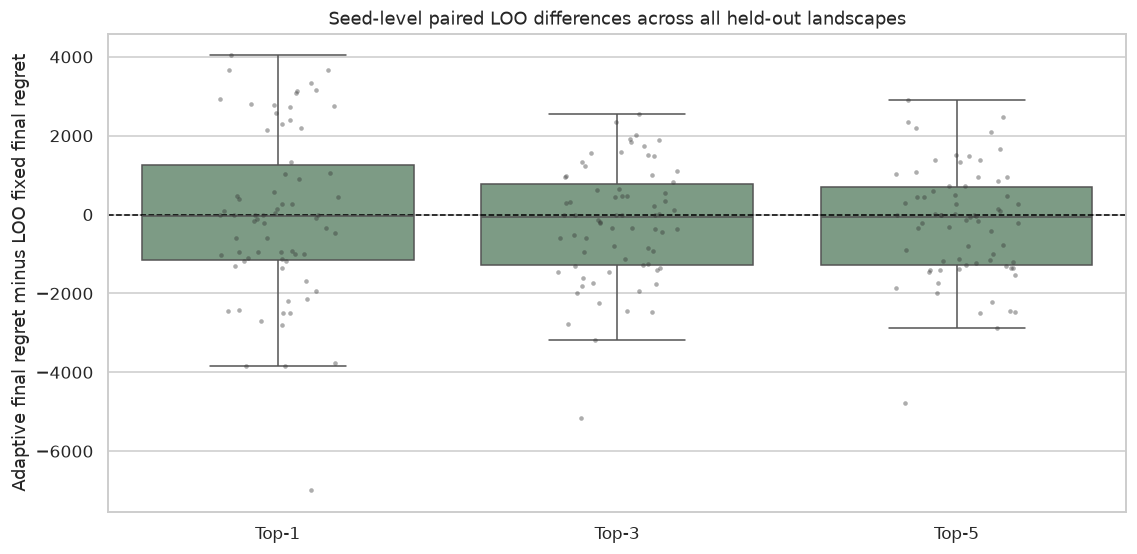

In [8]:

display(loo_summary.pivot(index='held_out_landscape', columns='strategy', values='mean_relative_to_oracle'))

paired = (loo_evaluation.pivot(index=['held_out_landscape', 'smac_seed'], columns='strategy', values='final_regret')
          .reset_index())
comparison_rows = []
for adaptive_strategy in [f'Top-{top_n} adaptive portfolio' for top_n in LOO_TOP_NS]:
    diff = paired[adaptive_strategy] - paired['LOO best fixed']
    wins = diff < 0
    for held_out, group in paired.assign(diff=diff, win=wins).groupby('held_out_landscape'):
        comparison_rows.append({
            'adaptive_strategy': adaptive_strategy,
            'held_out_landscape': held_out,
            'mean_adaptive_minus_loo_fixed': group['diff'].mean(),
            'median_adaptive_minus_loo_fixed': group['diff'].median(),
            'std': group['diff'].std(),
            'adaptive_win_rate_vs_loo_fixed': group['win'].mean(),
        })
comparison = pd.DataFrame(comparison_rows)
display(comparison.style.format({
    'mean_adaptive_minus_loo_fixed': '{:.5g}',
    'median_adaptive_minus_loo_fixed': '{:.5g}',
    'std': '{:.5g}',
    'adaptive_win_rate_vs_loo_fixed': '{:.1%}',
}))

fig, ax = plt.subplots(figsize=(10.5, 5.2))
diff_plot = []
for adaptive_strategy in [f'Top-{top_n} adaptive portfolio' for top_n in LOO_TOP_NS]:
    tmp = paired[['held_out_landscape', 'smac_seed']].copy()
    tmp['adaptive_strategy'] = adaptive_strategy.replace(' adaptive portfolio', '')
    tmp['adaptive_minus_loo_fixed'] = paired[adaptive_strategy] - paired['LOO best fixed']
    diff_plot.append(tmp)
diff_plot = pd.concat(diff_plot, ignore_index=True)
sns.boxplot(data=diff_plot, x='adaptive_strategy', y='adaptive_minus_loo_fixed', color='#78a083', ax=ax, showfliers=False)
sns.stripplot(data=diff_plot, x='adaptive_strategy', y='adaptive_minus_loo_fixed', color='0.2', alpha=0.4, jitter=0.18, size=3, ax=ax)
ax.axhline(0.0, color='black', lw=1, ls='--')
ax.set_xlabel('')
ax.set_ylabel('Adaptive final regret minus LOO fixed final regret')
ax.set_title('Seed-level paired LOO differences across all held-out landscapes')
fig.tight_layout()
plt.show()
